# Final Analysis Notebook

Spatial & Temporal Analysis first, followed by Severity Risk Factor Analysis.

## Part 1: Spatial & Temporal Analysis

# Spatial and Temporal Analysis

This notebook merges the original **Spatial Analysis** and **Temporal Analysis** notebooks with minimal changes. The main update is that both sections now use the uploaded dataset: `ANAC_final_tags.csv`.

## Shared Setup

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

DATA_FILE = "ANAC_final_tags.csv"


# Temporal Analysis

## Step 1: Load Data

In [60]:
df = pd.read_csv(DATA_FILE)

df["Publication Year"] = pd.to_numeric(df["Publication Year"], errors="coerce")
df = df.dropna(subset=["Publication Year"]).copy()
df["Publication Year"] = df["Publication Year"].astype(int)

print("Rows:", len(df))
print("Columns:", df.columns.tolist())
df.head()

Rows: 2769
Columns: ['ID', 'Accident Title', 'Publication Year', 'Text', 'Tags Applied', 'Country', 'State_Province', 'Country_std', 'State_Province_std', 'location_name', 'matched_phrase', 'lat', 'lon', 'severity', 'matched_terms', 'llm_experience_level', 'llm_experience_confidence', 'llm_experience_reason', 'llm_people_involved', 'llm_people_status', 'llm_people_confidence', 'llm_people_reason', 'llm_rescue_type', 'llm_rescue_confidence', 'llm_rescue_reason', 'llm_severity', 'llm_severity_confidence', 'llm_severity_reason', 'llm_cause', 'llm_cause_confidence', 'llm_cause_reason', 'llm_heuristics', 'llm_heuristics_confidence', 'llm_heuristics_reason', 'llm_heuristics_count', 'llm_participants_gender', 'llm_participants_gender_confidence', 'llm_participants_gender_reason', 'climb_tags', 'climb_primary', 'Helmet', 'Rope']


,ID,Accident Title,Publication Year,Text,Tags Applied,Country,State_Province,Country_std,State_Province_std,location_name,...,llm_heuristics_confidence,llm_heuristics_reason,llm_heuristics_count,llm_participants_gender,llm_participants_gender_confidence,llm_participants_gender_reason,climb_tags,climb_primary,Helmet,Rope
0,2,"Failure of Rappel—Failure to Check System, Bri...",1990,"British Columbia, Squamish, Smoke Bluffs\nOn M...","Experienced, Serious, Descent, Roped, Top-Rope...",CA,British Columbia,Canada,British Columbia,Grand Wall Area | aliases: Stawamus Chief|Squa...,...,85,Prior successful rappelling created a false se...,3,both,90,"The text explicitly mentions Deborah Richards,...","['alpine', 'rock']",rock,helmet,rope
1,3,"Fall into Crevasse, Climbing Alone, Inadequate...",1990,"Alberta, Rocky Mountains, Crowfoot Mountain\nO...","Experienced, Minor, Unroped , Solo, Climbing A...",CA,Alberta,Canada,Alberta,NaN,...,85,The glacier's appearance may have led F.E. to ...,1,men,90,The text explicitly states that the participan...,"['alpine', 'ice']",ice,unknown,unknown
2,4,"Fall into Crevasse, Climbing Unroped, British ...",1990,"British Columbia, Bugaboo Mountains, Bugaboo S...","Minor, Unroped , Solo, Alpine/Mountaineering, ...",CA,British Columbia,Canada,British Columbia,Bugaboo Spire | aliases: Bugaboos|Columbia-Shu...,...,90,Assumed the glacier was safe based on prior ex...,2,men,90,The text explicitly states that John Ulricson ...,"['alpine', 'rock', 'ice']",ice,helmet,no_rope
3,5,"Fall Into Crevasse, Unroped, Inadequate Equipm...",1990,"On the afternoon of March 29, 1989, four ski t...","Deadly, Serious, Descent, Unroped , Solo, Non-...",CA,Alberta,Canada,Alberta,NaN,...,80,"The practice of skiing unroped on glaciers, de...",2,unknown,80,The text does not clearly specify the genders ...,['alpine'],alpine,unknown,rope
4,6,"Fall into Moat, Descending Unroped, Poor Posit...",1990,"Alberta, Rocky Mountains, Mount Nublock\nLate ...","Deadly, Descent, Unroped , Solo, Alpine/Mounta...",CA,Alberta,Canada,Alberta,NaN,...,95,No clear cognitive heuristic present,0,unknown,80,The text does not clearly specify the gender o...,['alpine'],alpine,unknown,no_rope


## Step 2: Total incidents over time

   Publication Year  Incident Count
0              1990              81
1              1991              90
2              1992              90
3              1993              98
4              1994              89


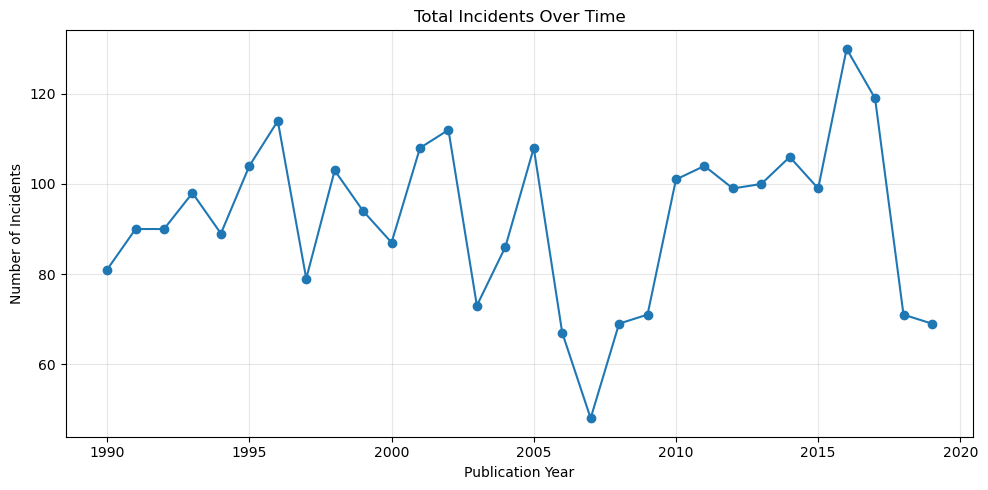

In [61]:
incidents_per_year = (
    df.groupby("Publication Year")
      .size()
      .reset_index(name="Incident Count")
      .sort_values("Publication Year")
)

print(incidents_per_year.head())

plt.figure(figsize=(10, 5))
plt.plot(
    incidents_per_year["Publication Year"],
    incidents_per_year["Incident Count"],
    marker="o"
)
plt.xlabel("Publication Year")
plt.ylabel("Number of Incidents")
plt.title("Total Incidents Over Time")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 3: Incidents per Year Bar Chart

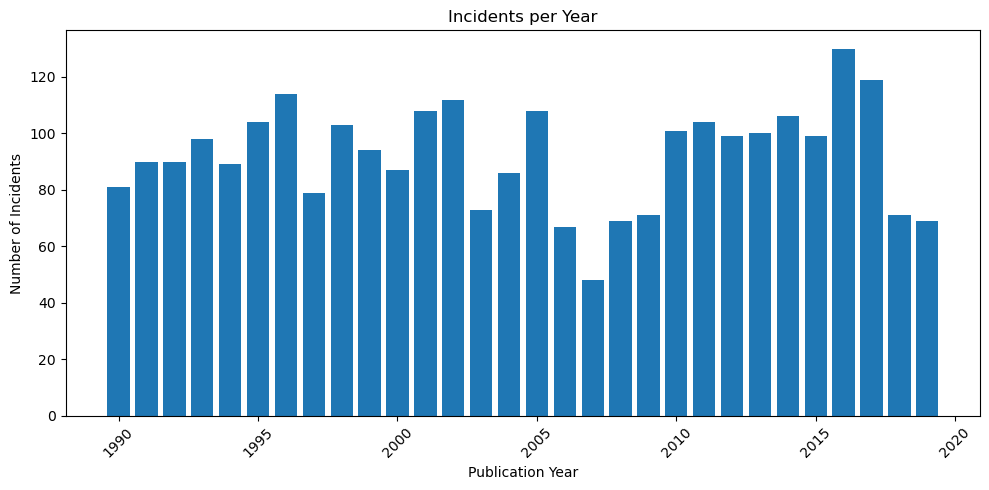

In [62]:
plt.figure(figsize=(10, 5))
plt.bar(
    incidents_per_year["Publication Year"],
    incidents_per_year["Incident Count"]
)
plt.xlabel("Publication Year")
plt.ylabel("Number of Incidents")
plt.title("Incidents per Year")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 5: Incidents Annual Count on Histogram

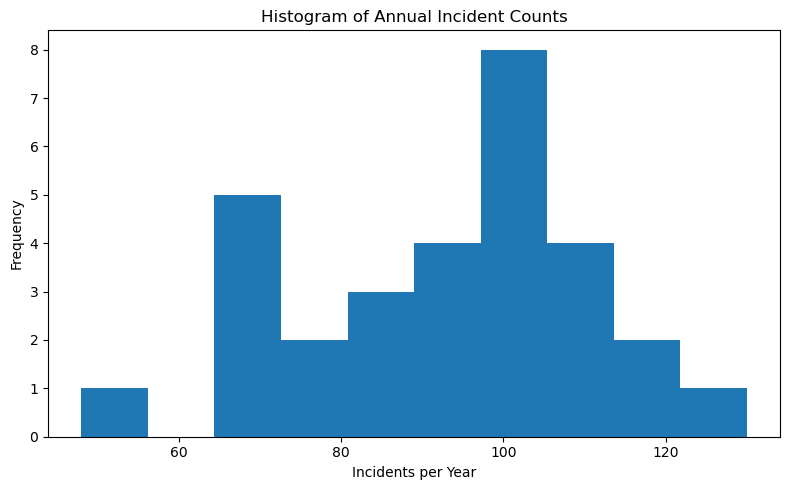

In [63]:
plt.figure(figsize=(8, 5))
plt.hist(incidents_per_year["Incident Count"], bins=10)
plt.xlabel("Incidents per Year")
plt.ylabel("Frequency")
plt.title("Histogram of Annual Incident Counts")
plt.tight_layout()
plt.show()

## Step 6: Linear Trend Line

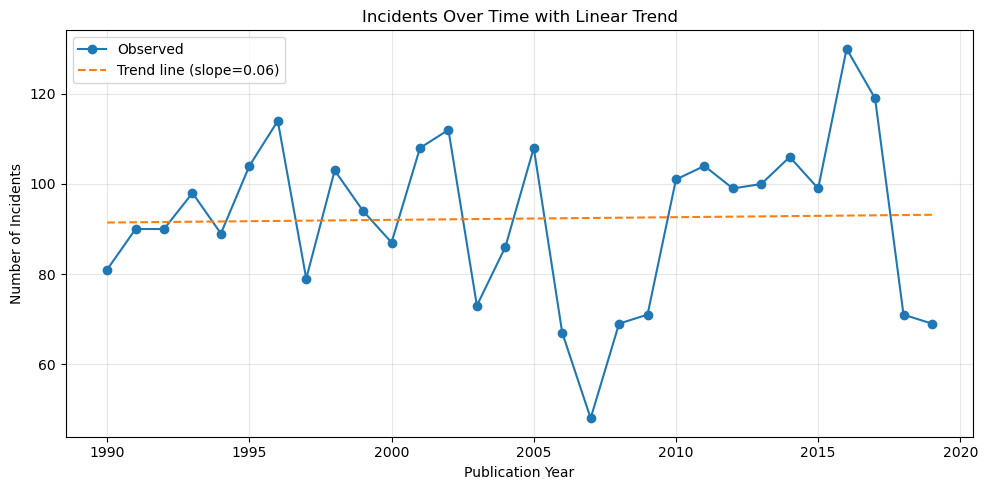

Linear trend slope: 0.0594
Overall trend: increasing


In [64]:
x = incidents_per_year["Publication Year"].values
y = incidents_per_year["Incident Count"].values

slope, intercept = np.polyfit(x, y, 1)
trend_line = slope * x + intercept

plt.figure(figsize=(10, 5))
plt.plot(x, y, marker="o", label="Observed")
plt.plot(x, trend_line, linestyle="--", label=f"Trend line (slope={slope:.2f})")
plt.xlabel("Publication Year")
plt.ylabel("Number of Incidents")
plt.title("Incidents Over Time with Linear Trend")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Linear trend slope: {slope:.4f}")
if slope > 0:
    print("Overall trend: increasing")
elif slope < 0:
    print("Overall trend: decreasing")
else:
    print("Overall trend: flat")

## Step 6: Discipline Categories

In [65]:
temporal_df = df.copy()

temporal_df["Rock"] = temporal_df["Tags Applied"].str.contains(
    "Trad|Sport|Top-Rope|Bouldering|Rock",
    case=False,
    na=False
)

temporal_df["Alpine"] = temporal_df["Tags Applied"].str.contains(
    "Alpine|Mountaineering",
    case=False,
    na=False
)

temporal_df["Ice"] = temporal_df["Tags Applied"].str.contains(
    "Ice",
    case=False,
    na=False
)

def get_discipline(row):
    if row["Ice"]:
        return "Ice"
    elif row["Alpine"]:
        return "Alpine"
    elif row["Rock"]:
        return "Rock"
    else:
        return "Other"

temporal_df["Discipline"] = temporal_df.apply(get_discipline, axis=1)

temporal_df[["Tags Applied", "Discipline"]].head()

,Tags Applied,Discipline
0,"Experienced, Serious, Descent, Roped, Top-Rope...",Rock
1,"Experienced, Minor, Unroped , Solo, Climbing A...",Ice
2,"Minor, Unroped , Solo, Alpine/Mountaineering, ...",Alpine
3,"Deadly, Serious, Descent, Unroped , Solo, Non-...",Alpine
4,"Deadly, Descent, Unroped , Solo, Alpine/Mounta...",Ice


Discipline        Alpine  Ice  Other  Rock
Publication Year                          
1990                  34   12     11    24
1991                  40   11     12    27
1992                  44   12     10    24
1993                  38   17     10    33
1994                  39    7     16    27


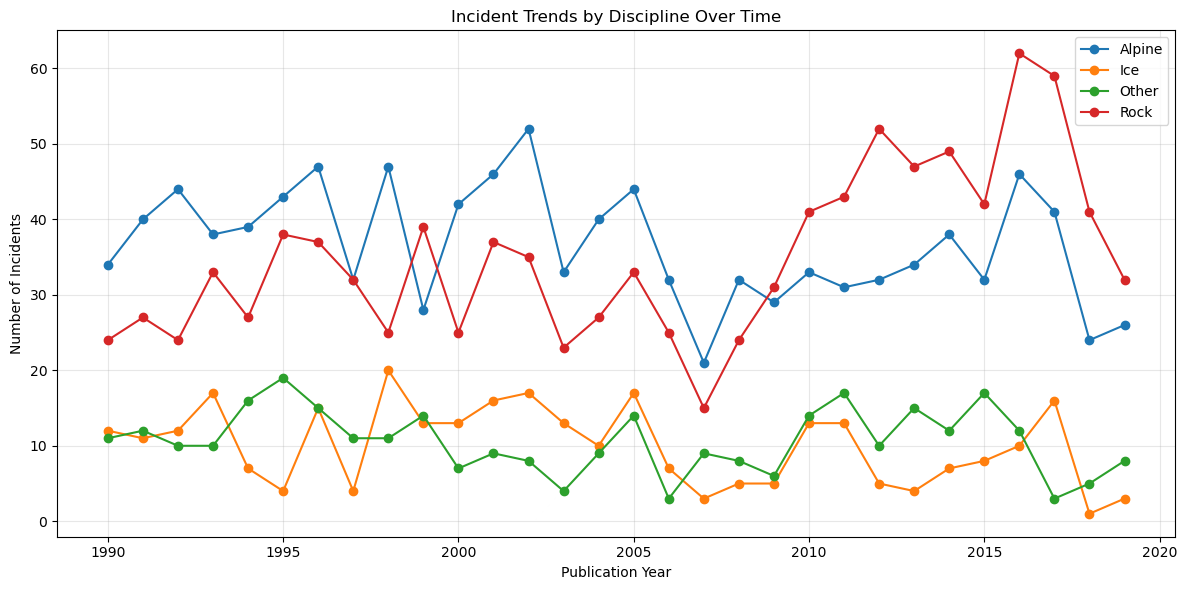

In [66]:
#Dispipline Trends Over Time

discipline_year = (
    temporal_df.groupby(["Publication Year", "Discipline"])
    .size()
    .reset_index(name="Incident Count")
)

discipline_pivot = discipline_year.pivot(
    index="Publication Year",
    columns="Discipline",
    values="Incident Count"
).fillna(0)

print(discipline_pivot.head())

plt.figure(figsize=(12, 6))
for col in discipline_pivot.columns:
    plt.plot(
        discipline_pivot.index,
        discipline_pivot[col],
        marker="o",
        label=col
    )

plt.xlabel("Publication Year")
plt.ylabel("Number of Incidents")
plt.title("Incident Trends by Discipline Over Time")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Severity          Deadly  Minor  Moderate  Serious  Unknown
Publication Year                                           
1990                  31      8         5       34        3
1991                  34      4        11       37        4
1992                  31      4        13       38        4
1993                  36      5         5       49        3
1994                  36      3        13       34        3


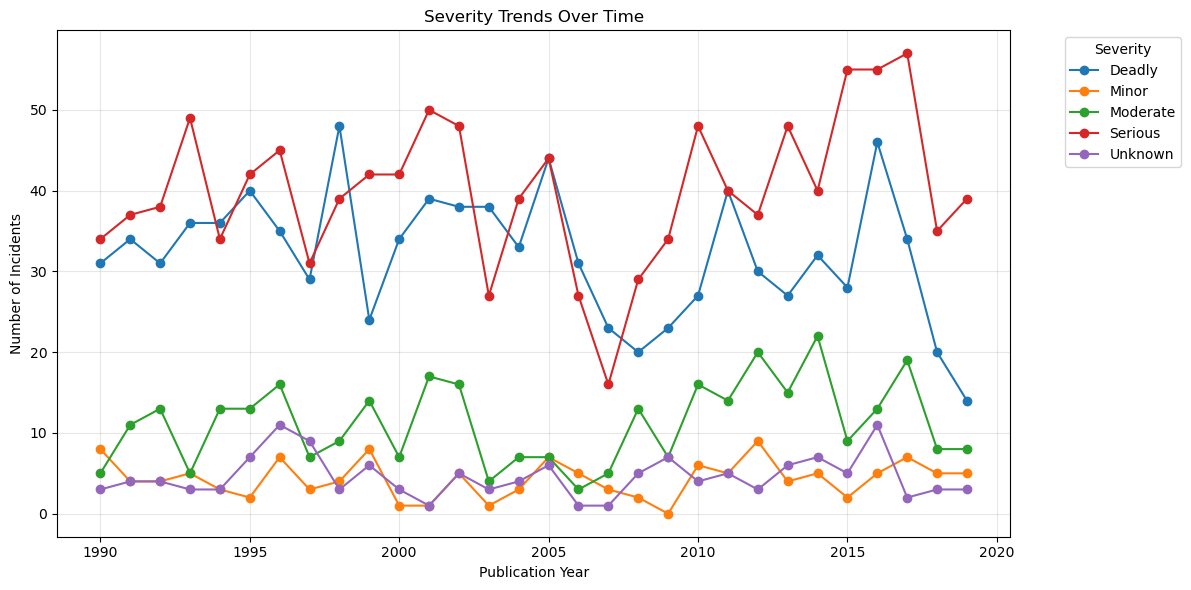

In [67]:
#Severity Trends over time

severity_df = df.copy()

severity_map = {
    "fatal": "Deadly",
    "serious": "Serious",
    "moderate": "Moderate",
    "minor": "Minor"
}

severity_df["Severity"] = (
    severity_df["severity"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
    .str.lower()
    .map(severity_map)
    .fillna("Unknown")
)

severity_pivot = (
    severity_df.groupby(["Publication Year", "Severity"])
    .size()
    .unstack(fill_value=0)
)

print(severity_pivot.head())

plt.figure(figsize=(12, 6))
for col in severity_pivot.columns:
    plt.plot(
        severity_pivot.index,
        severity_pivot[col],
        marker="o",
        label=col
    )

plt.xlabel("Publication Year")
plt.ylabel("Number of Incidents")
plt.title("Severity Trends Over Time")
plt.grid(True, alpha=0.3)
plt.legend(title="Severity", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Last step: I want to save the analysis into excel files for later prediction modeling

In [68]:
incidents_per_year.to_csv("incidents_per_year.csv", index=False)
discipline_pivot.to_csv("discipline_trends_by_year.csv")
severity_pivot.to_csv("severity_trends_by_year.csv")

print("Saved:")
print("- incidents_per_year.csv")
print("- discipline_trends_by_year.csv")
print("- severity_trends_by_year.csv")

Saved:
- incidents_per_year.csv
- discipline_trends_by_year.csv
- severity_trends_by_year.csv


# Spatial Analysis

## Map 1: Discipline Map

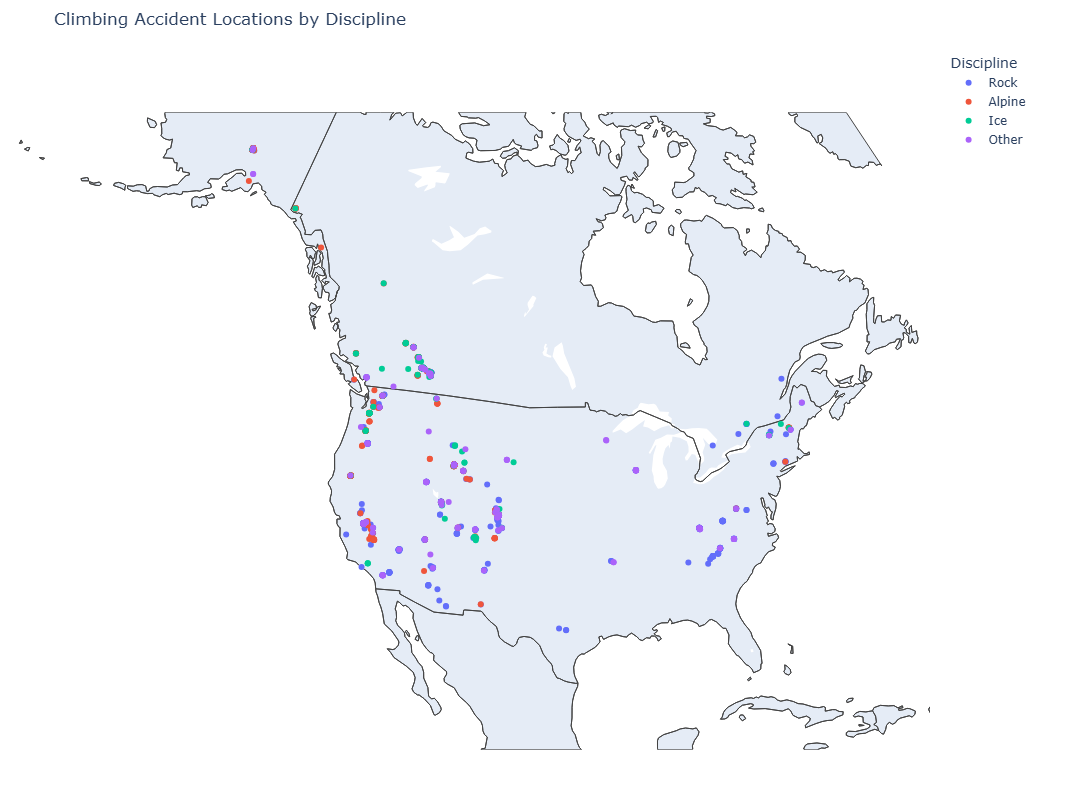

In [69]:
# Load data
map_df = pd.read_csv(DATA_FILE)

# Clean coordinates
map_df = map_df.dropna(subset=["lat", "lon"]).copy()
map_df["lat"] = pd.to_numeric(map_df["lat"], errors="coerce")
map_df["lon"] = pd.to_numeric(map_df["lon"], errors="coerce")

map_df = map_df.dropna(subset=["lat", "lon"]).copy()
map_df = map_df[
    map_df["lat"].between(-90, 90) &
    map_df["lon"].between(-180, 180)
].copy()

# Create discipline categories
map_df["Rock"] = map_df["Tags Applied"].str.contains(
    "Trad|Sport|Top-Rope|Bouldering|Rock",
    case=False,
    na=False
)

map_df["Alpine"] = map_df["Tags Applied"].str.contains(
    "Alpine|Mountaineering",
    case=False,
    na=False
)

map_df["Ice"] = map_df["Tags Applied"].str.contains(
    "Ice",
    case=False,
    na=False
)

def get_discipline(row):
    if row["Ice"]:
        return "Ice"
    elif row["Alpine"]:
        return "Alpine"
    elif row["Rock"]:
        return "Rock"
    else:
        return "Other"

map_df["Discipline"] = map_df.apply(get_discipline, axis=1)

# Add jitter
np.random.seed(42)
jitter_strength = 0.03

map_df["lat_jitter"] = map_df["lat"] + np.random.uniform(
    -jitter_strength, jitter_strength, size=len(map_df)
)
map_df["lon_jitter"] = map_df["lon"] + np.random.uniform(
    -jitter_strength, jitter_strength, size=len(map_df)
)

# Plot
fig = px.scatter_geo(
    map_df,
    lat="lat_jitter",
    lon="lon_jitter",
    color="Discipline",
    hover_name="Accident Title",
    hover_data={
        "Publication Year": True,
        "State_Province": True,
        "Country": True,
        "location_name": True,
        "severity": True
    },
    scope="north america",
    title="Climbing Accident Locations by Discipline"
)

fig.update_layout(
    width=1200,
    height=800,
    showlegend=True,
    legend_title="Discipline",
    legend=dict(
        x=1.02,
        y=1,
        xanchor="left",
        yanchor="top"
    ),
    margin={"r": 150, "t": 50, "l": 0, "b": 0}
)

fig.update_geos(
    showcountries=True,
    showcoastlines=True,
    showland=True,
    fitbounds="locations"
)

fig.show()

## Map 2: Severity Map

In [12]:
# Load data
map_df = pd.read_csv(DATA_FILE)

# Clean coordinates
map_df = map_df.dropna(subset=["lat", "lon"]).copy()
map_df["lat"] = pd.to_numeric(map_df["lat"], errors="coerce")
map_df["lon"] = pd.to_numeric(map_df["lon"], errors="coerce")

map_df = map_df.dropna(subset=["lat", "lon"]).copy()
map_df = map_df[
    map_df["lat"].between(-90, 90) &
    map_df["lon"].between(-180, 180)
].copy()

# Add jitter
np.random.seed(42)
jitter_strength = 0.03

map_df["lat_jitter"] = map_df["lat"] + np.random.uniform(
    -jitter_strength, jitter_strength, size=len(map_df)
)
map_df["lon_jitter"] = map_df["lon"] + np.random.uniform(
    -jitter_strength, jitter_strength, size=len(map_df)
)

# Clean severity
severity_map = {
    "fatal": "Deadly",
    "serious": "Serious",
    "moderate": "Moderate",
    "minor": "Minor"
}

map_df["Severity"] = (
    map_df["severity"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(severity_map)
    .fillna("Unknown")
)

severity_order = ["Deadly", "Serious", "Moderate", "Minor", "Unknown"]

# Plot
fig = px.scatter_geo(
    map_df,
    lat="lat_jitter",
    lon="lon_jitter",
    color="Severity",
    category_orders={"Severity": severity_order},
    hover_name="Accident Title",
    hover_data={
        "Publication Year": True,
        "State_Province": True,
        "Country": True,
        "location_name": True
    },
    scope="north america",
    title="Climbing Accident Locations by Severity"
)

fig.update_layout(
    width=1200,
    height=800,
    showlegend=True,
    legend_title="Severity",
    legend=dict(
        x=1.02,
        y=1,
        xanchor="left",
        yanchor="top"
    ),
    margin=dict(r=150, t=50, l=0, b=0)
)

fig.update_geos(
    showcountries=True,
    showcoastlines=True,
    showland=True,
    fitbounds="locations"
)

fig.show()

## Part 2: Severity Risk Factor Analysis

# Combined Severity Risk Factor Analysis

This notebook combines the following source notebooks into a single file while preserving the original code and outputs as closely as possible:

- `Severity_Risk_Factor_Analysis_Binary_Serious_vs_Death.ipynb`
- `Severity_Risk_Factor_Analysis_Tags_Applied_Column.ipynb`
- `Severity_Risk_Factor_Analysis_Updated.ipynb`

## Severity Risk Factor Analysis Binary Serious vs Death

# Severity Risk Factor Analysis — Binary Model (Serious vs Death)

This version keeps the same general workflow as the main notebook, but narrows the outcome to the two highest severity classes: **Serious** and **Death**.

### What changed
- Uses a **binary severity target**
  - `Serious`
  - `Death`
- **Excludes `moderate`, `minor`, and missing severity values**
- **Does not use `Tags Applied`**
- Keeps the structured tag-based approach from the main notebook
- Excludes columns that could leak the answer, including severity-related and reason-text fields

The goal here is to make the model easier to interpret by focusing only on the difference between severe non-fatal incidents and fatal incidents.

In [37]:
import ast
import re
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score
)

In [70]:
# Load the updated dataset
df = pd.read_csv("ANAC_final_tags.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
df.head()

Shape: (2770, 42)

Columns:
['ID', 'Accident Title', 'Publication Year', 'Text', 'Tags Applied', 'Country', 'State_Province', 'Country_std', 'State_Province_std', 'location_name', 'matched_phrase', 'lat', 'lon', 'severity', 'matched_terms', 'llm_experience_level', 'llm_experience_confidence', 'llm_experience_reason', 'llm_people_involved', 'llm_people_status', 'llm_people_confidence', 'llm_people_reason', 'llm_rescue_type', 'llm_rescue_confidence', 'llm_rescue_reason', 'llm_severity', 'llm_severity_confidence', 'llm_severity_reason', 'llm_cause', 'llm_cause_confidence', 'llm_cause_reason', 'llm_heuristics', 'llm_heuristics_confidence', 'llm_heuristics_reason', 'llm_heuristics_count', 'llm_participants_gender', 'llm_participants_gender_confidence', 'llm_participants_gender_reason', 'climb_tags', 'climb_primary', 'Helmet', 'Rope']


,ID,Accident Title,Publication Year,Text,Tags Applied,Country,State_Province,Country_std,State_Province_std,location_name,...,llm_heuristics_confidence,llm_heuristics_reason,llm_heuristics_count,llm_participants_gender,llm_participants_gender_confidence,llm_participants_gender_reason,climb_tags,climb_primary,Helmet,Rope
0,2,"Failure of Rappel—Failure to Check System, Bri...",1990.0,"British Columbia, Squamish, Smoke Bluffs\nOn M...","Experienced, Serious, Descent, Roped, Top-Rope...",CA,British Columbia,Canada,British Columbia,Grand Wall Area | aliases: Stawamus Chief|Squa...,...,85,Prior successful rappelling created a false se...,3,both,90,"The text explicitly mentions Deborah Richards,...","['alpine', 'rock']",rock,helmet,rope
1,3,"Fall into Crevasse, Climbing Alone, Inadequate...",1990.0,"Alberta, Rocky Mountains, Crowfoot Mountain\nO...","Experienced, Minor, Unroped , Solo, Climbing A...",CA,Alberta,Canada,Alberta,NaN,...,85,The glacier's appearance may have led F.E. to ...,1,men,90,The text explicitly states that the participan...,"['alpine', 'ice']",ice,unknown,unknown
2,4,"Fall into Crevasse, Climbing Unroped, British ...",1990.0,"British Columbia, Bugaboo Mountains, Bugaboo S...","Minor, Unroped , Solo, Alpine/Mountaineering, ...",CA,British Columbia,Canada,British Columbia,Bugaboo Spire | aliases: Bugaboos|Columbia-Shu...,...,90,Assumed the glacier was safe based on prior ex...,2,men,90,The text explicitly states that John Ulricson ...,"['alpine', 'rock', 'ice']",ice,helmet,no_rope
3,5,"Fall Into Crevasse, Unroped, Inadequate Equipm...",1990.0,"On the afternoon of March 29, 1989, four ski t...","Deadly, Serious, Descent, Unroped , Solo, Non-...",CA,Alberta,Canada,Alberta,NaN,...,80,"The practice of skiing unroped on glaciers, de...",2,unknown,80,The text does not clearly specify the genders ...,['alpine'],alpine,unknown,rope
4,6,"Fall into Moat, Descending Unroped, Poor Posit...",1990.0,"Alberta, Rocky Mountains, Mount Nublock\nLate ...","Deadly, Descent, Unroped , Solo, Alpine/Mounta...",CA,Alberta,Canada,Alberta,NaN,...,95,No clear cognitive heuristic present,0,unknown,80,The text does not clearly specify the gender o...,['alpine'],alpine,unknown,no_rope


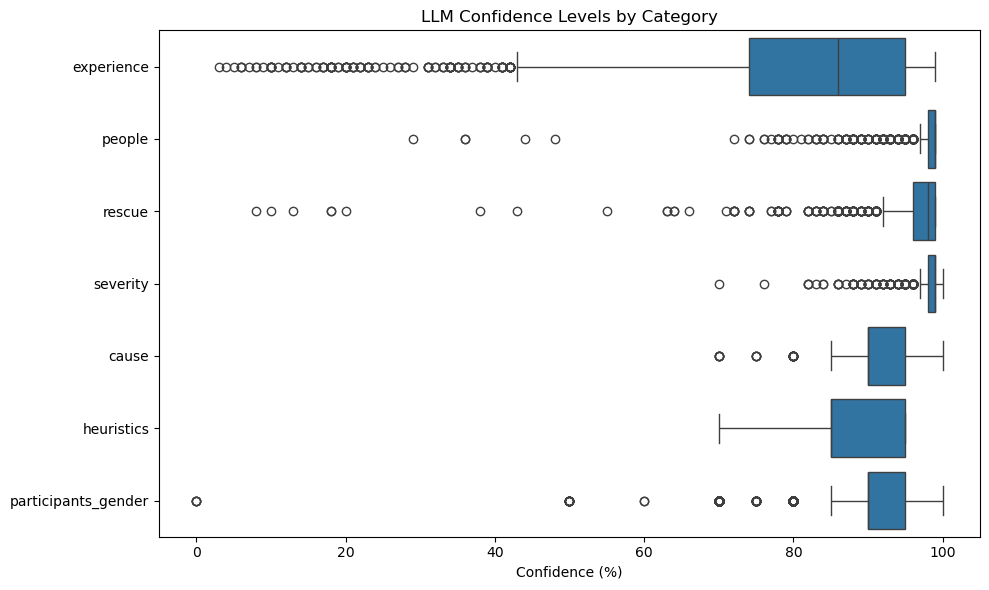

In [83]:
# get confidence for the llm columns
confidence_cols = [
    "llm_experience_confidence",
    "llm_people_confidence",
    "llm_rescue_confidence",
    "llm_severity_confidence",
    "llm_cause_confidence",
    "llm_heuristics_confidence",
    "llm_participants_gender_confidence"
]

# columns that need scaling
scale_cols = [
    "llm_experience_confidence",
    "llm_people_confidence",
    "llm_rescue_confidence",
    "llm_severity_confidence"
]

conf_df = model_df[confidence_cols].copy()
conf_df = conf_df.apply(pd.to_numeric, errors="coerce")

# scale selected columns
conf_df[scale_cols] = conf_df[scale_cols] * 100

# reshape
conf_long = conf_df.melt(var_name="Category", value_name="Confidence")

# clean labels
conf_long["Category"] = (
    conf_long["Category"]
    .str.replace("llm_", "", regex=False)
    .str.replace("_confidence", "", regex=False)
)

plt.figure(figsize=(10, 6))
sns.boxplot(data=conf_long, y="Category", x="Confidence")

plt.title("LLM Confidence Levels by Category")
plt.xlabel("Confidence (%)")
plt.ylabel("")

plt.tight_layout()
plt.show()

In [71]:
# Build the binary severity target:
# serious -> Serious
# fatal   -> Death
# moderate / minor / missing are excluded

severity_map = {
    "serious": "Serious",
    "fatal": "Death"
}

model_df = df.copy()
model_df["Severity2"] = (
    model_df["severity"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(severity_map)
)

model_df = model_df.dropna(subset=["Severity2"]).copy()

print(model_df["Severity2"].value_counts())

Severity2
Serious    1201
Death       965
Name: count, dtype: int64


In [72]:
# Helper functions to convert multi-tag fields into binary indicator columns

def split_csv_tags(x):
    if pd.isna(x):
        return []
    s = str(x).strip()
    if s == "" or s.lower() == "none":
        return []
    return [item.strip() for item in s.split(",") if item.strip()]

def parse_list_string(x):
    if pd.isna(x):
        return []
    s = str(x).strip()
    if s == "":
        return []
    try:
        parsed = ast.literal_eval(s)
        if isinstance(parsed, list):
            return [str(item).strip() for item in parsed if str(item).strip()]
    except Exception:
        pass
    return [item.strip() for item in re.split(r"[;,|]", s) if item.strip()]

def make_multihot(series, parser, prefix):
    parsed_lists = series.apply(parser)
    vocab = sorted({item for items in parsed_lists for item in items})
    out = pd.DataFrame(index=series.index)
    for item in vocab:
        safe_name = re.sub(r"[^0-9a-zA-Z_]+", "_", str(item)).strip("_").lower()
        col = f"{prefix}{safe_name}"
        out[col] = parsed_lists.apply(lambda items: int(item in items))
    return out

### Heuristics Feature

The `llm_heuristics` column contains short descriptions of contributing factors pulled from each incident. It’s text-based, but still pretty structured and useful.

In this step, we turn that text into something the model can use:

- clean up the text
- split it into individual terms or phrases
- convert those into binary features showing which heuristics are present

This helps the model pick up on patterns that may not be fully captured by the standard tag columns.

In [73]:
# Create binary columns from the multi-tag fields

heuristics_df = make_multihot(
    model_df["llm_heuristics"],
    parser=split_csv_tags,
    prefix="heuristic__"
)

climb_tags_df = make_multihot(
    model_df["climb_tags"],
    parser=parse_list_string,
    prefix="climb_tag__"
)

print("Heuristic tag columns:", heuristics_df.shape[1])
print("Climb tag columns:", climb_tags_df.shape[1])

heuristics_df.head()

Heuristic tag columns: 8
Climb tag columns: 3


,heuristic__acceptance,heuristic__back_to_the_barn,heuristic__blue_sky,heuristic__consistency,heuristic__expert_halo,heuristic__familiarity,heuristic__scarcity,heuristic__social_facilitation
0,0,0,0,1,1,1,0,0
3,1,0,0,0,0,1,0,0
4,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0
6,0,0,0,0,0,1,0,0


In [74]:
# Base structured features to keep
# NOTE:
# - We are NOT using Tags Applied
# - We are NOT using llm_severity / severity-derived columns
# - We are NOT using free-text reason columns
# - We are NOT using obvious ID or narrative text columns

base_features = model_df[
    [
        "Severity2",
        "llm_experience_level",
        "llm_people_involved",
        "llm_rescue_type",
        "llm_cause",
        "llm_participants_gender",
        "climb_primary",
        "Helmet",
        "Rope",
    ]
].copy()

# Combine base structured features with multi-hot tag features
full_model_df = pd.concat(
    [base_features, heuristics_df, climb_tags_df],
    axis=1
)

print("Modeling dataframe shape:", full_model_df.shape)
full_model_df.head()

Modeling dataframe shape: (2166, 20)


,Severity2,llm_experience_level,llm_people_involved,llm_rescue_type,llm_cause,llm_participants_gender,climb_primary,Helmet,Rope,heuristic__acceptance,heuristic__back_to_the_barn,heuristic__blue_sky,heuristic__consistency,heuristic__expert_halo,heuristic__familiarity,heuristic__scarcity,heuristic__social_facilitation,climb_tag__alpine,climb_tag__ice,climb_tag__rock
0,Serious,intermediate,2.0,professional_rescue,rappel_error,both,rock,helmet,rope,0,0,0,1,1,1,0,0,1,0,1
3,Death,expert,4.0,self_rescue,fall,unknown,alpine,unknown,rope,1,0,0,0,0,1,0,0,1,0,0
4,Death,intermediate,2.0,professional_rescue,fall,unknown,alpine,unknown,no_rope,0,0,0,0,0,0,0,0,1,0,0
5,Serious,intermediate,1.0,self_rescue,equipment_failure,men,rock,no_helmet,rope,0,0,0,0,0,0,0,0,1,0,1
6,Death,novice,2.0,professional_rescue,fall,men,rock,no_helmet,unknown,0,0,0,0,0,1,0,0,1,0,1


In [75]:
# Separate predictors and target

X = full_model_df.drop(columns=["Severity2"]).copy()
y = full_model_df["Severity2"].copy()

print("X shape:", X.shape)
print("y distribution:")
print(y.value_counts())

X shape: (2166, 19)
y distribution:
Severity2
Serious    1201
Death       965
Name: count, dtype: int64


### Why we separate feature groups during preprocessing

The dataset includes a mix of different types of data, and each type needs to be handled a little differently before going into the model.

To keep things clean and accurate, we split the features into groups:

- **categorical features** are one-hot encoded
- **numeric features** are imputed and scaled
- **tag / binary features** are already in a usable 0/1 format, so they can mostly pass through as-is

Separating the feature groups makes the pipeline easier to manage and helps make sure the model is learning from the data in a meaningful way.

In [76]:
# Separate feature groups for preprocessing

categorical_cols = [
    "llm_experience_level",
    "llm_rescue_type",
    "llm_cause",
    "llm_participants_gender",
    "climb_primary",
    "Helmet",
    "Rope",
]

numeric_cols = [
    "llm_people_involved",
]

binary_cols = [c for c in X.columns if c not in categorical_cols + numeric_cols]

print("Categorical:", len(categorical_cols))
print("Numeric:", len(numeric_cols))
print("Binary:", len(binary_cols))

Categorical: 7
Numeric: 1
Binary: 11


### Train/Test Split and Binary Logistic Regression

In this step, the data is split into training and testing sets so we can see how well the model performs on data it hasn’t seen before. The training set is used to fit the model, and the testing set is used to evaluate it.

We’re using logistic regression because the outcome now has only two classes: **Serious** and **Death**. The model estimates the probability of a fatal outcome based on the features in the dataset.

This approach works well for binary classification and is still easy to interpret, which is helpful for understanding which factors are associated with fatal versus non-fatal severe incidents.

In [77]:
# Train/test split and binary logistic regression

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore"))
                ]
            ),
            categorical_cols
        ),
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler())
                ]
            ),
            numeric_cols
        ),
        (
            "bin",
            "passthrough",
            binary_cols
        )
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                solver="liblinear",
                random_state=42
            )
        )
    ]
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, list(model.named_steps["classifier"].classes_).index("Death")]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("ROC AUC:", round(roc_auc_score((y_test == "Death").astype(int), y_proba), 4))
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.6402
ROC AUC: 0.6924

              precision    recall  f1-score   support

       Death       0.59      0.62      0.60       241
     Serious       0.68      0.66      0.67       301

    accuracy                           0.64       542
   macro avg       0.64      0.64      0.64       542
weighted avg       0.64      0.64      0.64       542



### Confusion Matrix

The confusion matrix shows how often the model predicted each class correctly and where it made mistakes.

Because this is a binary model, the table is easier to read than the three-class version. It gives a direct look at how often **Serious** cases were confused with **Death**, and vice versa.

This is useful because overall accuracy by itself can hide whether the model is better at identifying one class than the other.

Text(0.5, 23.38159722222222, 'Predicted')

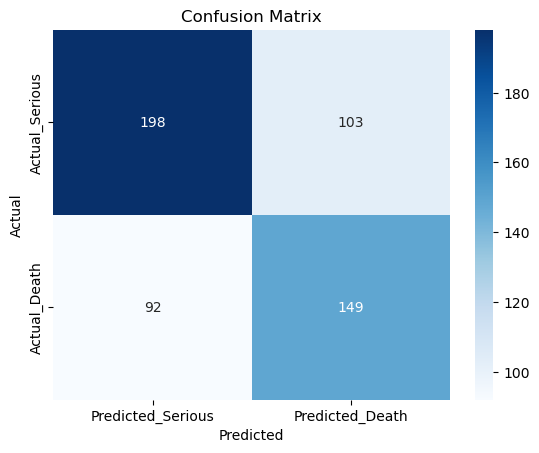

In [80]:
# Confusion matrix as a table and a plot

labels = ["Serious", "Death"]
cm = confusion_matrix(y_test, y_pred, labels=labels)

cm_df = pd.DataFrame(
    cm,
    index=[f"Actual_{label}" for label in labels],
    columns=[f"Predicted_{label}" for label in labels]
)

cm_df

sns.heatmap(
    cm_df,
    annot=True,      # show numbers
    fmt="d",         # integer formatting
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")

### Model Coefficients

This step extracts the coefficients from the trained logistic regression model so we can see which features are pushing predictions more toward **Death** or **Serious**.

For this binary model:

- **positive coefficients** increase the likelihood of `Death`
- **negative coefficients** increase the likelihood of `Serious`

This is one of the main reasons logistic regression is useful here. It gives a model that is still fairly interpretable.

In [47]:
# Extract model coefficients
# Positive coefficients push predictions toward Death
# Negative coefficients push predictions toward Serious

feature_names = model.named_steps["preprocessor"].get_feature_names_out()

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": model.named_steps["classifier"].coef_[0]
}).sort_values("coefficient", ascending=False)

coef_df.head()

,feature,coefficient
10,cat__llm_cause_falling_object,0.687693
5,cat__llm_rescue_type_self_rescue,0.631050
38,bin__heuristic__social_facilitation,0.558459
11,cat__llm_cause_illness,0.547681
8,cat__llm_cause_equipment_failure,0.545851


In [48]:
# Show strongest predictors for Death and Serious

print("=" * 80)
print("Top positive predictors for Death")
print(coef_df.head(20))

print("\n" + "=" * 80)
print("Top negative predictors for Serious")
print(coef_df.sort_values("coefficient", ascending=True).head(20))

Top positive predictors for Death
                                     feature  coefficient
10             cat__llm_cause_falling_object     0.687693
5           cat__llm_rescue_type_self_rescue     0.631050
38       bin__heuristic__social_facilitation     0.558459
11                    cat__llm_cause_illness     0.547681
8           cat__llm_cause_equipment_failure     0.545851
13              cat__llm_cause_stranded_lost     0.528251
28                            cat__Rope_rope     0.474469
9                        cat__llm_cause_fall     0.467953
37                  bin__heuristic__scarcity     0.436151
1     cat__llm_experience_level_intermediate     0.290747
4   cat__llm_rescue_type_professional_rescue     0.278437
22                   cat__climb_primary_rock     0.226884
26                       cat__Helmet_unknown     0.160831
19        cat__llm_participants_gender_women     0.158943
16         cat__llm_participants_gender_both     0.118207
29                         cat__Rope_u

### Odds Ratios for Model Interpretation

In this step, the model coefficients are converted into odds ratios so they’re easier to read.

- values **above 1** mean the feature increases the likelihood of `Death`
- values **below 1** mean the feature increases the likelihood of `Serious`

This makes the size of each effect a little more intuitive than raw coefficients alone.

In [49]:
# Odds ratios for easier interpretation

odds_ratio_df = coef_df.copy()
odds_ratio_df["odds_ratio"] = np.exp(odds_ratio_df["coefficient"])

print("Highest odds ratios for Death")
print(odds_ratio_df.sort_values("odds_ratio", ascending=False).head(20))

print("\n" + "=" * 80)
print("Lowest odds ratios (more associated with Serious)")
print(odds_ratio_df.sort_values("odds_ratio", ascending=True).head(20))

Highest odds ratios for Death
                                     feature  coefficient  odds_ratio
10             cat__llm_cause_falling_object     0.687693    1.989121
5           cat__llm_rescue_type_self_rescue     0.631050    1.879583
38       bin__heuristic__social_facilitation     0.558459    1.747976
11                    cat__llm_cause_illness     0.547681    1.729238
8           cat__llm_cause_equipment_failure     0.545851    1.726076
13              cat__llm_cause_stranded_lost     0.528251    1.695964
28                            cat__Rope_rope     0.474469    1.607160
9                        cat__llm_cause_fall     0.467953    1.596722
37                  bin__heuristic__scarcity     0.436151    1.546743
1     cat__llm_experience_level_intermediate     0.290747    1.337427
4   cat__llm_rescue_type_professional_rescue     0.278437    1.321063
22                   cat__climb_primary_rock     0.226884    1.254685
26                       cat__Helmet_unknown     0.160831   

## How to interpret the output

A few reminders when reading the results:

- One-hot encoded categorical variables will appear with prefixes like `cat__`
- Numeric features will appear with prefixes like `num__`
- Binary tag columns will appear with prefixes like `bin__`

In this binary version:
- a **positive coefficient** means the feature is more associated with `Death`
- a **negative coefficient** means the feature is more associated with `Serious`

This notebook is meant to answer a narrower question than the multi-class version: which factors separate fatal incidents from other high-severity, non-fatal incidents?

### Results Summary and Comparison to Three-Class Model

This version of the model focuses only on distinguishing between **Serious** and **Death** outcomes, which simplifies the prediction task compared to the original three-class model.

Overall, the binary model performs better than the three-class version. This is expected, since the model only needs to separate two classes instead of three, and it removes the smaller and harder-to-predict **Moderate** category. As a result, predictions are more stable and the model is better at identifying patterns associated specifically with fatal outcomes.

Looking at the results, many of the same key drivers of severity still appear. **High-risk incident types**, such as avalanches and certain fall-related scenarios, remain strong predictors of death. The heuristics features also continue to play an important role, especially those related to decision-making and environmental conditions. These features help capture context that isn’t fully represented by the structured tag columns.

At the same time, the binary model provides a clearer separation between outcomes. Features associated with **non-fatal serious incidents** (such as self-rescue, being stranded, or lower-impact situations) are more clearly distinguished from those linked to fatal outcomes. This makes the coefficients and odds ratios easier to interpret, since they now directly reflect the difference between surviving and not surviving.

Compared to the three-class model:

* The binary model is **easier to interpret**, since every feature is evaluated in terms of increasing or decreasing the likelihood of death
* It shows **stronger and more consistent signals** for key predictors
* It avoids some of the confusion seen in the three-class model, especially around the Moderate category
* However, it **loses some granularity**, since it no longer distinguishes between Moderate and Serious outcomes

In summary, the binary model is more effective for identifying what drives **fatal vs non-fatal severe incidents**, while the three-class model is better for understanding the full spectrum of severity. The two approaches complement each other, depending on whether the goal is detailed categorization or clearer risk separation.


## Severity Risk Factor Analysis Tags Applied Column

### Data Loading

This step loads the dataset and prepares it for analysis.

In [26]:
#Load and Inspect the most up-to-date CSV file

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("ANAC_final_tags.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Shape: (2770, 42)

Columns:
['ID', 'Accident Title', 'Publication Year', 'Text', 'Tags Applied', 'Country', 'State_Province', 'Country_std', 'State_Province_std', 'location_name', 'matched_phrase', 'lat', 'lon', 'severity', 'matched_terms', 'llm_experience_level', 'llm_experience_confidence', 'llm_experience_reason', 'llm_people_involved', 'llm_people_status', 'llm_people_confidence', 'llm_people_reason', 'llm_rescue_type', 'llm_rescue_confidence', 'llm_rescue_reason', 'llm_severity', 'llm_severity_confidence', 'llm_severity_reason', 'llm_cause', 'llm_cause_confidence', 'llm_cause_reason', 'llm_heuristics', 'llm_heuristics_confidence', 'llm_heuristics_reason', 'llm_heuristics_count', 'llm_participants_gender', 'llm_participants_gender_confidence', 'llm_participants_gender_reason', 'climb_tags', 'climb_primary', 'Helmet', 'Rope']


,ID,Accident Title,Publication Year,Text,Tags Applied,Country,State_Province,Country_std,State_Province_std,location_name,...,llm_heuristics_confidence,llm_heuristics_reason,llm_heuristics_count,llm_participants_gender,llm_participants_gender_confidence,llm_participants_gender_reason,climb_tags,climb_primary,Helmet,Rope
0,2,"Failure of Rappel—Failure to Check System, Bri...",1990.0,"British Columbia, Squamish, Smoke Bluffs\nOn M...","Experienced, Serious, Descent, Roped, Top-Rope...",CA,British Columbia,Canada,British Columbia,Grand Wall Area | aliases: Stawamus Chief|Squa...,...,85,Prior successful rappelling created a false se...,3,both,90,"The text explicitly mentions Deborah Richards,...","['alpine', 'rock']",rock,helmet,rope
1,3,"Fall into Crevasse, Climbing Alone, Inadequate...",1990.0,"Alberta, Rocky Mountains, Crowfoot Mountain\nO...","Experienced, Minor, Unroped , Solo, Climbing A...",CA,Alberta,Canada,Alberta,NaN,...,85,The glacier's appearance may have led F.E. to ...,1,men,90,The text explicitly states that the participan...,"['alpine', 'ice']",ice,unknown,unknown
2,4,"Fall into Crevasse, Climbing Unroped, British ...",1990.0,"British Columbia, Bugaboo Mountains, Bugaboo S...","Minor, Unroped , Solo, Alpine/Mountaineering, ...",CA,British Columbia,Canada,British Columbia,Bugaboo Spire | aliases: Bugaboos|Columbia-Shu...,...,90,Assumed the glacier was safe based on prior ex...,2,men,90,The text explicitly states that John Ulricson ...,"['alpine', 'rock', 'ice']",ice,helmet,no_rope
3,5,"Fall Into Crevasse, Unroped, Inadequate Equipm...",1990.0,"On the afternoon of March 29, 1989, four ski t...","Deadly, Serious, Descent, Unroped , Solo, Non-...",CA,Alberta,Canada,Alberta,NaN,...,80,"The practice of skiing unroped on glaciers, de...",2,unknown,80,The text does not clearly specify the genders ...,['alpine'],alpine,unknown,rope
4,6,"Fall into Moat, Descending Unroped, Poor Posit...",1990.0,"Alberta, Rocky Mountains, Mount Nublock\nLate ...","Deadly, Descent, Unroped , Solo, Alpine/Mounta...",CA,Alberta,Canada,Alberta,NaN,...,95,No clear cognitive heuristic present,0,unknown,80,The text does not clearly specify the gender o...,['alpine'],alpine,unknown,no_rope


In [27]:
#Now we want to clean the severity field and create a binary outcome. For example: 1 = fatal or serious and 0 = moderate or minor

# Clean severity labels
severity_map = {
    "fatal": "Deadly",
    "serious": "Serious",
    "moderate": "Moderate",
    "minor": "Minor"
}

df["Severity"] = (
    df["severity"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(severity_map)
)

df = df.dropna(subset=["Severity"]).copy()

# Binary outcome: severe vs non-severe
df["Severe"] = df["Severity"].isin(["Deadly", "Serious"]).astype(int)

print(df["Severity"].value_counts())
print("\nSevere rate:")
print(df["Severe"].mean())

Severity
Serious     1201
Deadly       965
Moderate     337
Minor        129
Name: count, dtype: int64

Severe rate:
0.8229483282674772


### Tags Applied Processing

The `Tags Applied` column contains combined tag information. In this step, the tags are parsed and converted into a structured format that can be used in the model.

In [28]:
#The next step is to create a discipline category from the tags that were applied

df["Rock"] = df["Tags Applied"].str.contains(
    "Trad|Sport|Top-Rope|Bouldering|Rock",
    case=False,
    na=False
)

df["Alpine"] = df["Tags Applied"].str.contains(
    "Alpine|Mountaineering",
    case=False,
    na=False
)

df["Ice"] = df["Tags Applied"].str.contains(
    "Ice",
    case=False,
    na=False
)

def get_discipline(row):
    if row["Ice"]:
        return "Ice"
    elif row["Alpine"]:
        return "Alpine"
    elif row["Rock"]:
        return "Rock"
    else:
        return "Other"

df["Discipline"] = df.apply(get_discipline, axis=1)

print(df["Discipline"].value_counts())
df[["Tags Applied", "Discipline"]].head(10)

Discipline
Alpine    1040
Rock      1006
Other      294
Ice        292
Name: count, dtype: int64


,Tags Applied,Discipline
0,"Experienced, Serious, Descent, Roped, Top-Rope...",Rock
1,"Experienced, Minor, Unroped , Solo, Climbing A...",Ice
2,"Minor, Unroped , Solo, Alpine/Mountaineering, ...",Alpine
3,"Deadly, Serious, Descent, Unroped , Solo, Non-...",Alpine
4,"Deadly, Descent, Unroped , Solo, Alpine/Mounta...",Ice
5,"Serious, Roped, Trad Climbing, Inadequate Prot...",Rock
6,"No/Little, Deadly, Serious, Unroped , Solo, No...",Other
7,"Deadly, Serious, Unroped , Solo, No Helmet, La...",Other
8,"Experienced, Serious, Roped, Trad Climbing, In...",Rock
9,"Serious, Head / Brain Injury, Roped, Trad Clim...",Rock


            Severe Rate  Total Accidents  Severe Accidents
Discipline                                                
Ice            0.876712              292               256
Alpine         0.826923             1040               860
Rock           0.821074             1006               826
Other          0.761905              294               224


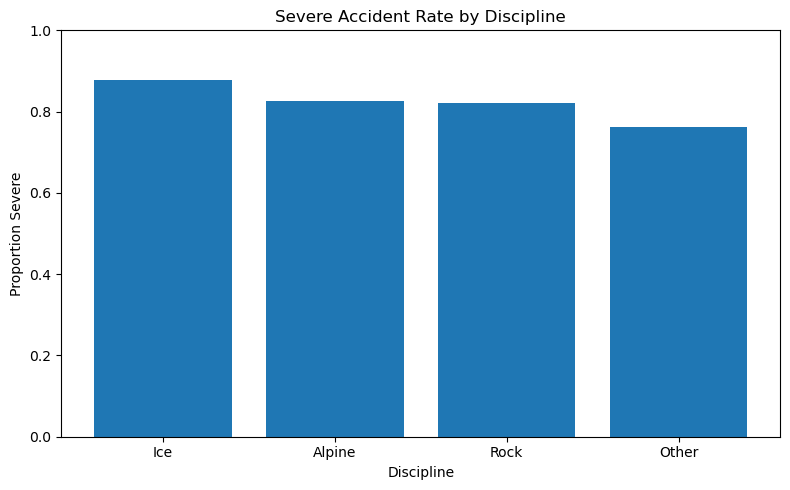

In [29]:
# SO now i want to find out the severity rate by each discipline

severity_by_discipline = (
    df.groupby("Discipline")["Severe"]
      .agg(["mean", "count", "sum"])
      .sort_values("mean", ascending=False)
)

severity_by_discipline = severity_by_discipline.rename(columns={
    "mean": "Severe Rate",
    "count": "Total Accidents",
    "sum": "Severe Accidents"
})

print(severity_by_discipline)

plt.figure(figsize=(8, 5))
plt.bar(severity_by_discipline.index, severity_by_discipline["Severe Rate"])
plt.ylabel("Proportion Severe")
plt.xlabel("Discipline")
plt.title("Severe Accident Rate by Discipline")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

Severity      Deadly     Minor  Moderate   Serious
Discipline                                        
Alpine      0.412500  0.045192  0.127885  0.414423
Ice         0.452055  0.023973  0.099315  0.424658
Other       0.411565  0.078231  0.159864  0.350340
Rock        0.281312  0.051690  0.127237  0.539761


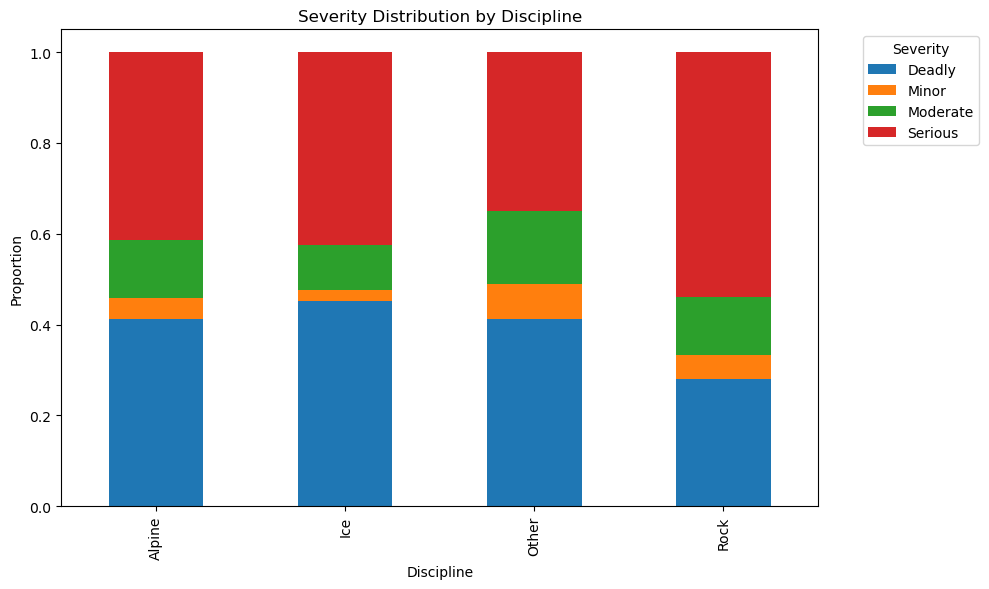

In [30]:
# Severity Distribution by Discipline as a stacked proportion

discipline_severity_table = pd.crosstab(df["Discipline"], df["Severity"])

discipline_severity_prop = discipline_severity_table.div(
    discipline_severity_table.sum(axis=1), axis=0
)

print(discipline_severity_prop)

discipline_severity_prop.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.ylabel("Proportion")
plt.xlabel("Discipline")
plt.title("Severity Distribution by Discipline")
plt.legend(title="Severity", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Tags Applied Processing

The `Tags Applied` column contains combined tag information. In this step, the tags are parsed and converted into a structured format that can be used in the model.

In [31]:
#Another good idea for us is to split the tags applied into individual tags so we can look at the details

tag_df = df.copy()

tag_df["Tag_List"] = tag_df["Tags Applied"].fillna("").str.split(",")

tag_df = tag_df.explode("Tag_List").copy()
tag_df["Tag_List"] = tag_df["Tag_List"].str.strip()

# Remove blanks
tag_df = tag_df[tag_df["Tag_List"] != ""].copy()

print(tag_df[["Tags Applied", "Tag_List"]].head(10))
print("\nUnique tags:", tag_df["Tag_List"].nunique())


                                        Tags Applied             Tag_List
0  Experienced, Serious, Descent, Roped, Top-Rope...          Experienced
0  Experienced, Serious, Descent, Roped, Top-Rope...              Serious
0  Experienced, Serious, Descent, Roped, Top-Rope...              Descent
0  Experienced, Serious, Descent, Roped, Top-Rope...                Roped
0  Experienced, Serious, Descent, Roped, Top-Rope...             Top-Rope
0  Experienced, Serious, Descent, Roped, Top-Rope...  Knot & Tie-in Error
0  Experienced, Serious, Descent, Roped, Top-Rope...         Rappel Error
1  Experienced, Minor, Unroped , Solo, Climbing A...          Experienced
1  Experienced, Minor, Unroped , Solo, Climbing A...                Minor
1  Experienced, Minor, Unroped , Solo, Climbing A...              Unroped

Unique tags: 69


In [32]:
#Now by using the seperated tags, we can find out the severe accident rate by tag

tag_severity = (
    tag_df.groupby("Tag_List")["Severe"]
          .agg(["mean", "count", "sum"])
          .sort_values(["mean", "count"], ascending=[False, False])
)

tag_severity = tag_severity.rename(columns={
    "mean": "Severe Rate",
    "count": "Total Cases",
    "sum": "Severe Cases"
})

# Optional: only keep tags with enough observations
tag_severity_filtered = tag_severity[tag_severity["Total Cases"] >= 10]

print(tag_severity_filtered.head(20))

                                Severe Rate  Total Cases  Severe Cases
Tag_List                                                              
Deadly                             0.996403          556           554
Avalanche                          0.960938          128           123
Head / Brain Injury                0.948399          562           533
Aid & Big Wall                     0.944444           54            51
Gear Broke                         0.937500           64            60
Poor Cond/Seasonal Risk            0.926471           68            63
Run Out                            0.916667           84            77
Cornice / Snow Bridge Collapse     0.916667           48            44
Ledge Fall                         0.913043           69            63
Natural Rockfall                   0.912088           91            83
Handhold/Foothold Broke            0.911565          147           134
Anchor Failure / Error             0.906977          129           117
Rushed

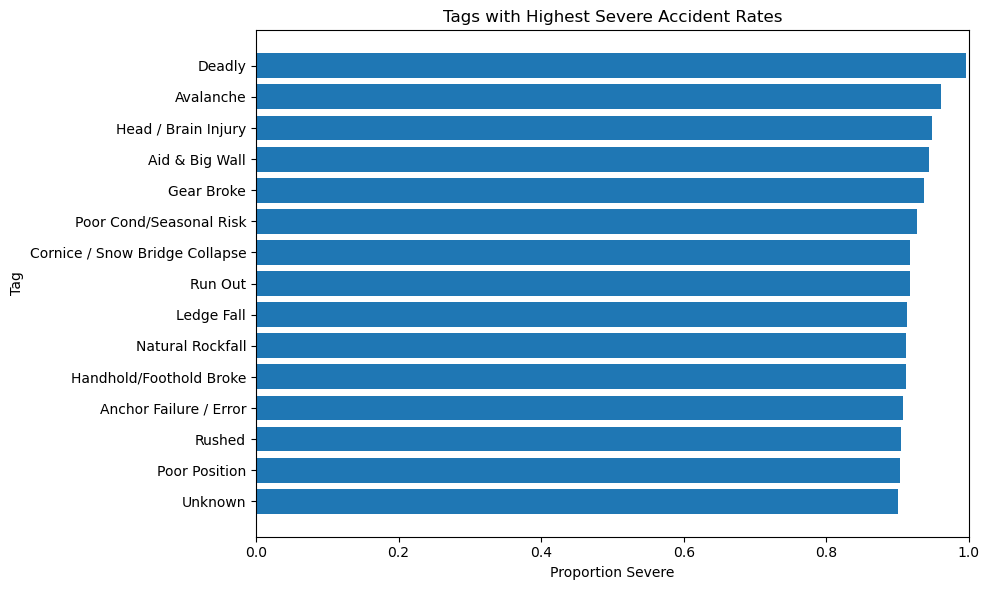

In [33]:
#Now create a plot that has the tags with the highest severitity rates

top_tags = tag_severity_filtered.head(15).sort_values("Severe Rate", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_tags.index, top_tags["Severe Rate"])
plt.xlabel("Proportion Severe")
plt.ylabel("Tag")
plt.title("Tags with Highest Severe Accident Rates")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

                  Severe Rate  Total Accidents  Severe Accidents
Publication Year                                                
1990                 0.833333               78                65
1991                 0.825581               86                71
1992                 0.802326               86                69
1993                 0.894737               95                85
1994                 0.813953               86                70


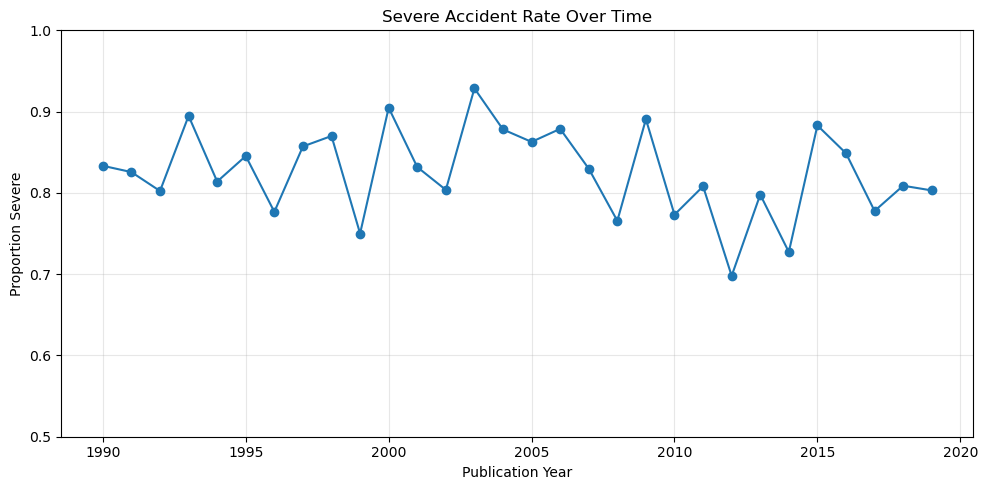

In [34]:
#nOw more basic analyses: severity by year

df["Publication Year"] = pd.to_numeric(df["Publication Year"], errors="coerce")
year_df = df.dropna(subset=["Publication Year"]).copy()
year_df["Publication Year"] = year_df["Publication Year"].astype(int)

severity_by_year = (
    year_df.groupby("Publication Year")["Severe"]
           .agg(["mean", "count", "sum"])
           .rename(columns={
               "mean": "Severe Rate",
               "count": "Total Accidents",
               "sum": "Severe Accidents"
           })
)

print(severity_by_year.head())

plt.figure(figsize=(10, 5))
plt.plot(severity_by_year.index, severity_by_year["Severe Rate"], marker="o")
plt.xlabel("Publication Year")
plt.ylabel("Proportion Severe")
plt.title("Severe Accident Rate Over Time")
plt.ylim(0.5, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
#Severity by location

location_severity = (
    df.groupby("State_Province")["Severe"]
      .agg(["mean", "count", "sum"])
      .rename(columns={
          "mean": "Severe Rate",
          "count": "Total Accidents",
          "sum": "Severe Accidents"
      })
)

location_severity_filtered = (
    location_severity[location_severity["Total Accidents"] >= 10]
    .sort_values("Severe Rate", ascending=False)
)

print(location_severity_filtered.head(15))

                  Severe Rate  Total Accidents  Severe Accidents
State_Province                                                  
Ontario              1.000000               11                11
Quebec               0.937500               16                15
New Mexico           0.933333               15                14
Montana              0.916667               12                11
Yukon                0.900000               10                 9
Idaho                0.875000               24                21
New York             0.860000               50                43
Alaska               0.856164              292               250
Utah                 0.853659               82                70
California           0.852732              421               359
North Carolina       0.850000               80                68
Washington           0.846847              222               188
British Columbia     0.839623              106                89
Oregon               0.83

In [36]:
# I want to check whether the disciplines are related to severity by using a Chi-square test

from scipy.stats import chi2_contingency

contingency = pd.crosstab(df["Discipline"], df["Severe"])
print(contingency)

chi2, p, dof, expected = chi2_contingency(contingency)

print("\nChi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

if p < 0.05:
    print("Result: Discipline and severity are significantly associated.")
else:
    print("Result: No statistically significant association found.")

Severe        0    1
Discipline          
Alpine      180  860
Ice          36  256
Other        70  224
Rock        180  826

Chi-square statistic: 13.44880255216863
p-value: 0.0037600506985496244
Degrees of freedom: 3
Result: Discipline and severity are significantly associated.


### Train/Test Split

The data is split into training and testing sets to evaluate model performance on unseen data.

In [37]:
#Now for the predictive modeling. I want to incorporate a linear regression model. Because 0 and 1 are inbalanced, I had to create a class weight 

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

model_df = df.copy()

model_df = model_df[["Severe", "Discipline", "State_Province", "Publication Year"]].copy()

model_df["Publication Year"] = pd.to_numeric(model_df["Publication Year"], errors="coerce")
model_df = model_df.dropna(subset=["Publication Year"]).copy()

model_df["State_Province"] = model_df["State_Province"].fillna("Unknown")
model_df["Discipline"] = model_df["Discipline"].fillna("Other")

# Collapse rare states into "Other"
state_counts = model_df["State_Province"].value_counts()
rare_states = state_counts[state_counts < 10].index
model_df["State_Province"] = model_df["State_Province"].replace(rare_states, "Other")

X = model_df[["Discipline", "State_Province", "Publication Year"]]
y = model_df["Severe"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

categorical_features = ["Discipline", "State_Province"]
numeric_features = ["Publication Year"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features)
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="liblinear"
    ))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.5825426944971537

Confusion Matrix:
[[ 40  53]
 [167 267]]

Classification Report:
              precision    recall  f1-score   support

           0       0.19      0.43      0.27        93
           1       0.83      0.62      0.71       434

    accuracy                           0.58       527
   macro avg       0.51      0.52      0.49       527
weighted avg       0.72      0.58      0.63       527



### Tags Applied Processing

The `Tags Applied` column contains combined tag information. In this step, the tags are parsed and converted into a structured format that can be used in the model.

In [38]:
#This model above is a good baseline, but now I want to do a predicitve model with the tag features. BUT I need to 
#remove all severity tags because this is a severity target model. 

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

model_df = df.copy()

# Keep needed columns
model_df = model_df[["Severe", "Discipline", "State_Province", "Publication Year", "Tags Applied"]].copy()

# Clean fields
model_df["Publication Year"] = pd.to_numeric(model_df["Publication Year"], errors="coerce")
model_df = model_df.dropna(subset=["Publication Year"]).copy()

model_df["State_Province"] = model_df["State_Province"].fillna("Unknown")
model_df["Discipline"] = model_df["Discipline"].fillna("Other")
model_df["Tags Applied"] = model_df["Tags Applied"].fillna("")

# Collapse rare states into "Other"
state_counts = model_df["State_Province"].value_counts()
rare_states = state_counts[state_counts < 10].index
model_df["State_Province"] = model_df["State_Province"].replace(rare_states, "Other")

# Create tag indicator columns
tag_counts = (
    model_df["Tags Applied"]
    .dropna()
    .astype(str)
    .str.lower()
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
)

print("Top 30 tags:")
print(tag_counts.head(30))

# Tags to exclude because they leak severity/outcome information
exclude_tags = [
    "serious",
    "minor",
    "fatal",
    "moderate",
    "deadly",
    "head / brain injury"
]

# Select most common non-leaking tags
top_n = 20
candidate_tags = tag_counts.index.tolist()
tag_keywords = [tag for tag in candidate_tags if tag not in exclude_tags][:top_n]

print("\nUsing these tags in model:")
print(tag_keywords)

for tag in tag_keywords:
    col_name = "tag_" + tag.replace(" ", "_")
    model_df[col_name] = model_df["Tags Applied"].str.contains(tag, case=False, na=False).astype(int)

# Features and target
tag_feature_cols = ["tag_" + tag.replace(" ", "_") for tag in tag_keywords]

X = model_df[["Discipline", "State_Province", "Publication Year"] + tag_feature_cols]
y = model_df["Severe"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

categorical_features = ["Discipline", "State_Province"]
numeric_features = ["Publication Year"]
binary_tag_features = tag_feature_cols

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features),
        ("tags", "passthrough", binary_tag_features)
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="liblinear"
    ))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Top 30 tags:
Tags Applied
serious                           1812
roped                             1521
alpine/mountaineering             1208
trad climbing                      868
descent                            833
no/little                          593
inadequate protection / pulled     589
experienced                        568
head / brain injury                562
deadly                             556
unroped                            554
solo                               516
stranded / lost / overdue          288
minor                              254
no helmet                          245
exposure                           239
rappel error                       237
inadequate equipment               229
visibility                         228
severe weather                     222
off-route                          221
ice climbing                       214
fatigue                            173
sport                              162
late in day                        159

In [39]:
#extract the coefficients from this model pipeline

import pandas as pd

# Get feature names after preprocessing
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

# Get coefficients from logistic regression
coefficients = pd.Series(
    model.named_steps["classifier"].coef_[0],
    index=feature_names
).sort_values(ascending=False)

print("Top positive coefficients (increase severe risk):")
print(coefficients.head(20))

print("\nTop negative coefficients (decrease severe risk):")
print(coefficients.tail(20))

Top positive coefficients (increase severe risk):
cat__State_Province_Quebec                  1.031708
cat__State_Province_Ontario                 0.988402
tags__tag_exposure                          0.910800
tags__tag_solo                              0.814017
tags__tag_ice_climbing                      0.755494
tags__tag_severe_weather                    0.744773
cat__State_Province_Yukon                   0.710816
tags__tag_rappel_error                      0.672139
tags__tag_alpine/mountaineering             0.649747
cat__State_Province_Utah                    0.556007
cat__State_Province_California              0.520911
tags__tag_experienced                       0.490449
tags__tag_no_helmet                         0.447139
cat__State_Province_New Mexico              0.443448
tags__tag_inadequate_protection_/_pulled    0.411081
cat__State_Province_North Carolina          0.370142
cat__State_Province_Pennsylvania            0.348558
cat__State_Province_New York                0.337

In [40]:
#Print the odd ratios

import numpy as np

odds_ratios = pd.Series(
    np.exp(model.named_steps["classifier"].coef_[0]),
    index=feature_names
).sort_values(ascending=False)

print("Top odds ratios (higher severe risk):")
print(odds_ratios.head(20))

print("\nLowest odds ratios (lower severe risk):")
print(odds_ratios.tail(20))

Top odds ratios (higher severe risk):
cat__State_Province_Quebec                  2.805855
cat__State_Province_Ontario                 2.686938
tags__tag_exposure                          2.486311
tags__tag_solo                              2.256956
tags__tag_ice_climbing                      2.128663
tags__tag_severe_weather                    2.105964
cat__State_Province_Yukon                   2.035651
tags__tag_rappel_error                      1.958422
tags__tag_alpine/mountaineering             1.915056
cat__State_Province_Utah                    1.743695
cat__State_Province_California              1.683561
tags__tag_experienced                       1.633049
tags__tag_no_helmet                         1.563831
cat__State_Province_New Mexico              1.558070
tags__tag_inadequate_protection_/_pulled    1.508448
cat__State_Province_North Carolina          1.447940
cat__State_Province_Pennsylvania            1.417023
cat__State_Province_New York                1.401236
tags__ta

## Feature Name Legend (Model Interpretation Guide)

This guide explains how to interpret features after preprocessing


### Prefixes

* **`cat__`** → Categorical variables (one-hot encoded)

  * Examples:

    * `cat__Discipline_Alpine`
    * `cat__State_Province_Colorado`

* **`num__`** → Numeric variables (scaled)

  * Example:

    * `num__Publication Year`

* **`tags__`** → Tag indicator variables (from `"Tags Applied"`)

  * Examples:

    * `tags__tag_solo`
    * `tags__tag_rappel_error`
    * `tags__tag_no_helmet`


### How to read categorical features

Example:

```
cat__Discipline_Alpine
```

Means:

* This row is **1 if Alpine climbing**, 0 otherwise
* Compared against the baseline (the category that was dropped, e.g., Rock or Other)


### How to read tag features

Example:

```
tags__tag_solo
```

Means:

* This accident involved **solo climbing**

Example:

```
tags__tag_no_helmet
```

Means:

* The climber was **not wearing a helmet**

These are the most important features for answering:

> *What contributes to severe accidents?*


### How to interpret coefficients

* **Positive coefficient** → increases likelihood of a severe accident
* **Negative coefficient** → decreases likelihood


### How to interpret odds ratios

* **> 1** → increases risk
* **< 1** → decreases risk

Example:

```
tags__tag_solo = 2.0
```

→ Solo climbing **doubles the odds** of a severe accident


### Important note (baseline categories)

Because of one-hot encoding (`drop="first"`):

* One category is omitted as the baseline
* All other categories are interpreted **relative to that baseline**


### Focus for analysis

The most meaningful predictors will usually be:

* `tags__...` → accident type / behavior
* `cat__Discipline_...` → type of climbing
* `cat__State_Province_...` → location effects


### Summary

* `cat__` → category comparisons
* `tags__` → accident characteristics (**most important**)
* `num__` → trends over time


### Final Model Comparison and Conclusion

This model represents the original approach using the **“Tags Applied”** column, where all tags are combined into a single text field and then processed for use in the model. It serves as a useful baseline for comparison against the more structured approaches.

In terms of performance, this model achieved **lower overall accuracy (around 35–40%)** compared to the structured tag model (~48%) and the binary Serious vs Death model (which performed even better due to the simpler task). It also showed weaker precision and recall across all classes, especially for the **Moderate** category, which was often misclassified.

Compared to the model using **separate structured tag columns (O–AP)**, this approach struggles because the tag information is less organized. When all tags are combined into a single field, the model has a harder time isolating the impact of individual factors. This leads to weaker and less consistent predictors, as well as more confusion between **Serious** and **Death** outcomes in the confusion matrix.

The **binary Serious vs Death model** further highlights this difference. By focusing only on two classes and using structured inputs, that model produced clearer separation between outcomes, along with stronger and more interpretable coefficients. In contrast, the Tags Applied model spreads the signal across many combined features, making it harder to clearly identify what drives severity.

Another limitation of this approach is interpretability. Because the tags are embedded in one text column, it is more difficult to directly compare individual risk factors. The structured model, on the other hand, allows each tag to be evaluated independently, which makes the results much easier to understand and act on.

Looking across all three models:

* The **Tags Applied model** had the lowest performance (~35–40% accuracy) and the most difficulty separating severity levels
* The **structured tag model (O–AP columns)** improved accuracy (~48%) and produced more meaningful feature insights
* The **binary Serious vs Death model** performed best overall, with stronger separation and clearer interpretation of fatal risk

Overall, these results show that **feature structure plays a major role in model performance**. Moving from a combined text field to structured tag columns significantly improves both predictive accuracy and interpretability. Narrowing the problem further to a binary classification adds even more clarity when the goal is to understand what drives fatal outcomes.

Together, these three models show a clear progression from a simple baseline to a more refined and effective predictive approach.


## Severity Risk Factor Analysis Updated

# Severity Risk Factor Analysis — Tag-Based Model Using our Created Tags

This version removes the dependency on the **`Tags Applied`** column from ANAC and instead builds the predictive model from the structured tag columns in the updated file that our group completed.

### What changed
- Uses a **3-class severity target**:
  - `Moderate`
  - `Serious`
  - `Death`
- **Excludes `minor`** from the target
- **Does not use `Tags Applied`**
- Combines the other structured columns, including multi-tag columns like:
  - `llm_heuristics`
  - `climb_tags`
  - plus other categorical tag fields such as `llm_cause`, `climb_primary`, `Helmet`, and `Rope`

### Important modeling choice
To avoid target leakage, this notebook **does not use**:
- `severity` itself as a feature
- `llm_severity`
- `llm_severity_confidence`
- `llm_severity_reason`
- `matched_terms`
- free-text `*_reason` columns

In [50]:
import ast
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [51]:
# Load the updated dataset
df = pd.read_csv("ANAC_final_tags.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
df.head()

Shape: (2770, 42)

Columns:
['ID', 'Accident Title', 'Publication Year', 'Text', 'Tags Applied', 'Country', 'State_Province', 'Country_std', 'State_Province_std', 'location_name', 'matched_phrase', 'lat', 'lon', 'severity', 'matched_terms', 'llm_experience_level', 'llm_experience_confidence', 'llm_experience_reason', 'llm_people_involved', 'llm_people_status', 'llm_people_confidence', 'llm_people_reason', 'llm_rescue_type', 'llm_rescue_confidence', 'llm_rescue_reason', 'llm_severity', 'llm_severity_confidence', 'llm_severity_reason', 'llm_cause', 'llm_cause_confidence', 'llm_cause_reason', 'llm_heuristics', 'llm_heuristics_confidence', 'llm_heuristics_reason', 'llm_heuristics_count', 'llm_participants_gender', 'llm_participants_gender_confidence', 'llm_participants_gender_reason', 'climb_tags', 'climb_primary', 'Helmet', 'Rope']


,ID,Accident Title,Publication Year,Text,Tags Applied,Country,State_Province,Country_std,State_Province_std,location_name,...,llm_heuristics_confidence,llm_heuristics_reason,llm_heuristics_count,llm_participants_gender,llm_participants_gender_confidence,llm_participants_gender_reason,climb_tags,climb_primary,Helmet,Rope
0,2,"Failure of Rappel—Failure to Check System, Bri...",1990.0,"British Columbia, Squamish, Smoke Bluffs\nOn M...","Experienced, Serious, Descent, Roped, Top-Rope...",CA,British Columbia,Canada,British Columbia,Grand Wall Area | aliases: Stawamus Chief|Squa...,...,85,Prior successful rappelling created a false se...,3,both,90,"The text explicitly mentions Deborah Richards,...","['alpine', 'rock']",rock,helmet,rope
1,3,"Fall into Crevasse, Climbing Alone, Inadequate...",1990.0,"Alberta, Rocky Mountains, Crowfoot Mountain\nO...","Experienced, Minor, Unroped , Solo, Climbing A...",CA,Alberta,Canada,Alberta,NaN,...,85,The glacier's appearance may have led F.E. to ...,1,men,90,The text explicitly states that the participan...,"['alpine', 'ice']",ice,unknown,unknown
2,4,"Fall into Crevasse, Climbing Unroped, British ...",1990.0,"British Columbia, Bugaboo Mountains, Bugaboo S...","Minor, Unroped , Solo, Alpine/Mountaineering, ...",CA,British Columbia,Canada,British Columbia,Bugaboo Spire | aliases: Bugaboos|Columbia-Shu...,...,90,Assumed the glacier was safe based on prior ex...,2,men,90,The text explicitly states that John Ulricson ...,"['alpine', 'rock', 'ice']",ice,helmet,no_rope
3,5,"Fall Into Crevasse, Unroped, Inadequate Equipm...",1990.0,"On the afternoon of March 29, 1989, four ski t...","Deadly, Serious, Descent, Unroped , Solo, Non-...",CA,Alberta,Canada,Alberta,NaN,...,80,"The practice of skiing unroped on glaciers, de...",2,unknown,80,The text does not clearly specify the genders ...,['alpine'],alpine,unknown,rope
4,6,"Fall into Moat, Descending Unroped, Poor Posit...",1990.0,"Alberta, Rocky Mountains, Mount Nublock\nLate ...","Deadly, Descent, Unroped , Solo, Alpine/Mounta...",CA,Alberta,Canada,Alberta,NaN,...,95,No clear cognitive heuristic present,0,unknown,80,The text does not clearly specify the gender o...,['alpine'],alpine,unknown,no_rope


In [52]:
# Build the 3-class severity target:
# moderate -> Moderate
# serious  -> Serious
# fatal    -> Death
# minor is excluded from the modeling target

severity_map = {
    "moderate": "Moderate",
    "serious": "Serious",
    "fatal": "Death"
}

model_df = df.copy()
model_df["Severity3"] = (
    model_df["severity"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(severity_map)
)

model_df = model_df.dropna(subset=["Severity3"]).copy()

print(model_df["Severity3"].value_counts())

Severity3
Serious     1201
Death        965
Moderate     337
Name: count, dtype: int64


### Severity distribution

This chart shows the class balance in the final modeling dataset after `minor` cases are removed and the three severity groups are created.


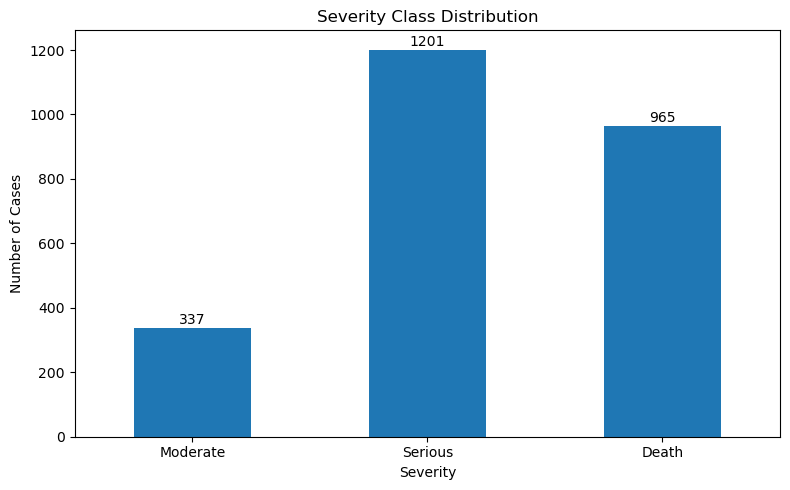

In [53]:
# Visualize the severity distribution in the final modeling dataset

severity_counts = model_df["Severity3"].value_counts().reindex(["Moderate", "Serious", "Death"])

ax = severity_counts.plot(kind="bar", figsize=(8, 5))
plt.title("Severity Class Distribution")
plt.xlabel("Severity")
plt.ylabel("Number of Cases")

for i, value in enumerate(severity_counts.values):
    ax.text(i, value + max(severity_counts.values) * 0.01, str(value), ha="center")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

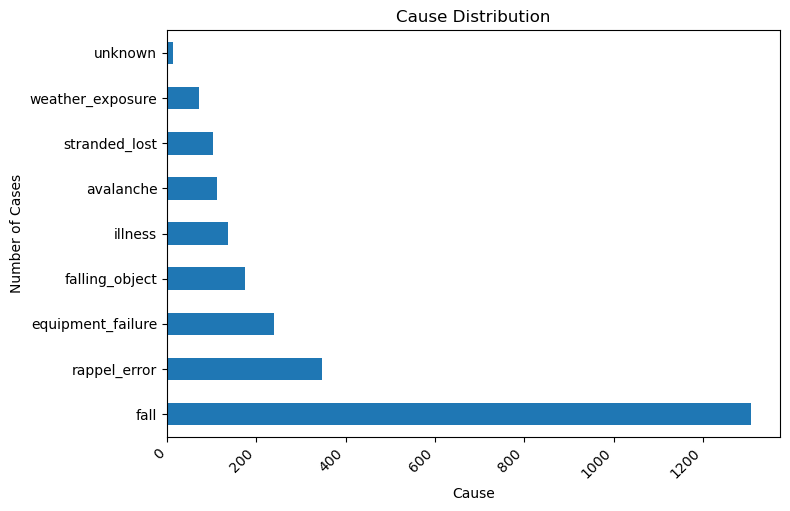

In [69]:
# graphing the distribution of causes
cause_counts = model_df["llm_cause"].value_counts()

ax = cause_counts.plot(kind="barh", figsize=(8, 5))
plt.title("Cause Distribution")
plt.xlabel("Cause")
plt.ylabel("Number of Cases")



plt.xticks(rotation=0)
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

In [54]:
# Helper functions to convert multi-tag fields into binary indicator columns

def split_csv_tags(x):
    if pd.isna(x):
        return []
    s = str(x).strip()
    if s == "" or s.lower() == "none":
        return []
    return [item.strip() for item in s.split(",") if item.strip()]

def parse_list_string(x):
    if pd.isna(x):
        return []
    s = str(x).strip()
    if s == "":
        return []
    try:
        parsed = ast.literal_eval(s)
        if isinstance(parsed, list):
            return [str(item).strip() for item in parsed if str(item).strip()]
    except Exception:
        pass
    return [item.strip() for item in re.split(r"[,|;/]", s) if item.strip()]

def make_multihot(series, parser, prefix):
    parsed = series.apply(parser)
    vocab = sorted({
        item for sublist in parsed for item in sublist
        if item and item.lower() not in {"none", "unknown"}
    })
    out = pd.DataFrame(
        0,
        index=series.index,
        columns=[f"{prefix}{item}" for item in vocab],
        dtype=int
    )
    for idx, items in parsed.items():
        for item in items:
            if item and item.lower() not in {"none", "unknown"}:
                out.at[idx, f"{prefix}{item}"] = 1
    return out

### Heuristics Feature

The `llm_heuristics` column contains short descriptions of contributing factors pulled from each incident (things like decision-making, environment, or equipment issues). It’s text-based, but still pretty structured and useful.

In this step, we turn that text into something the model can use:

* Clean up the text (lowercase, consistent formatting)
* Break it into individual terms or phrases
* Convert those into numeric features (basically tracking which heuristics are present)

This lets the model pick up on patterns like certain behaviors or conditions being linked to more severe outcomes.

We include heuristics because they capture useful context that isn’t always covered by the tag columns. At the same time, we avoid using the `*_reason` fields since those often include outcome-related language and would introduce data leakage.

Overall, this step helps bring in more detail about what contributed to each incident without giving away the answer.


In [55]:
# Create binary columns from the multi-tag fields

heuristics_df = make_multihot(
    model_df["llm_heuristics"],
    parser=split_csv_tags,
    prefix="heuristic__"
)

climb_tags_df = make_multihot(
    model_df["climb_tags"],
    parser=parse_list_string,
    prefix="climb_tag__"
)

print("Heuristic tag columns:", heuristics_df.shape[1])
print("Climb tag columns:", climb_tags_df.shape[1])

heuristics_df.head()

Heuristic tag columns: 8
Climb tag columns: 3


,heuristic__acceptance,heuristic__back_to_the_barn,heuristic__blue_sky,heuristic__consistency,heuristic__expert_halo,heuristic__familiarity,heuristic__scarcity,heuristic__social_facilitation
0,0,0,0,1,1,1,0,0
2,0,0,1,0,0,1,0,0
3,1,0,0,0,0,1,0,0
4,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0


### Most common tag and heuristic features

These plots give a quick look at which structured tag columns and heuristic terms show up most often in the dataset.

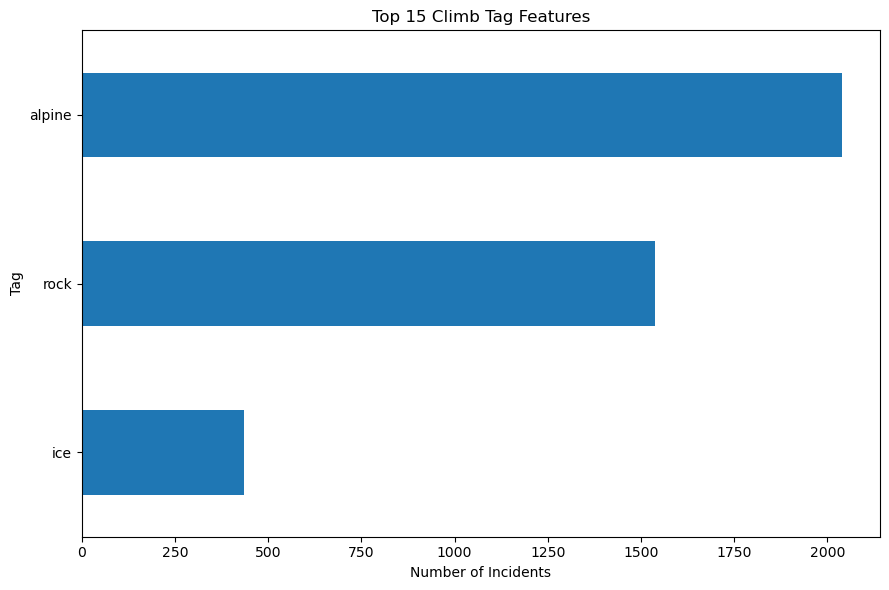

In [56]:
# Plot the most common climb tags

top_climb_tags = climb_tags_df.sum().sort_values(ascending=False).head(15)
top_climb_tags.index = top_climb_tags.index.str.replace("climb_tag__", "", regex=False)

ax = top_climb_tags.sort_values().plot(kind="barh", figsize=(9, 6))
plt.title("Top 15 Climb Tag Features")
plt.xlabel("Number of Incidents")
plt.ylabel("Tag")
plt.tight_layout()
plt.show()


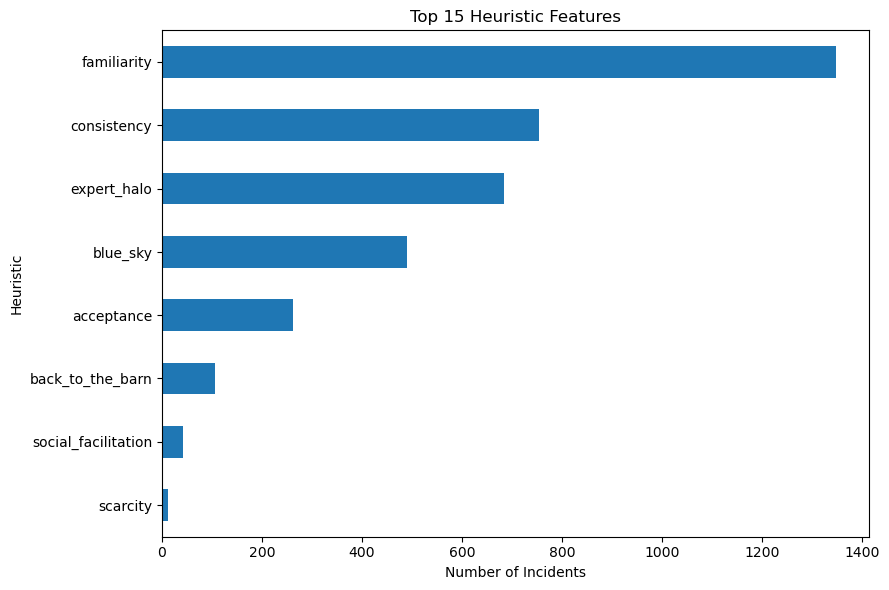

In [24]:
# Plot the most common heuristic terms

top_heuristics = heuristics_df.sum().sort_values(ascending=False).head(15)
top_heuristics.index = top_heuristics.index.str.replace("heuristic__", "", regex=False)

ax = top_heuristics.sort_values().plot(kind="barh", figsize=(9, 6))
plt.title("Top 15 Heuristic Features")
plt.xlabel("Number of Incidents")
plt.ylabel("Heuristic")
plt.tight_layout()
plt.show()

In [57]:
# Base structured features to keep
# NOTE:
# - We are NOT using Tags Applied
# - We are NOT using llm_severity / severity-derived columns
# - We are NOT using free-text reason columns
# - The "reason" texts can slowly leak the answer and make the model look smarter than it is. 

base_features = model_df[
    [
        "Severity3",
        "llm_experience_level",
        "llm_people_involved",
        "llm_rescue_type",
        "llm_cause",
        "llm_participants_gender",
        "climb_primary",
        "Helmet",
        "Rope",
    ]
].copy()


base_features["llm_people_involved"] = pd.to_numeric(
    base_features["llm_people_involved"], errors="coerce"
)



# Collapse rare states so the model doesn't overfit tiny categories



# Combine all predictors
X = pd.concat(
    [base_features.drop(columns=["Severity3"]), heuristics_df, climb_tags_df],
    axis=1
)
y = base_features["Severity3"]

print("Modeling rows:", len(X))
print("Total feature columns before encoding:", X.shape[1])
X.head()

Modeling rows: 2503
Total feature columns before encoding: 19


,llm_experience_level,llm_people_involved,llm_rescue_type,llm_cause,llm_participants_gender,climb_primary,Helmet,Rope,heuristic__acceptance,heuristic__back_to_the_barn,heuristic__blue_sky,heuristic__consistency,heuristic__expert_halo,heuristic__familiarity,heuristic__scarcity,heuristic__social_facilitation,climb_tag__alpine,climb_tag__ice,climb_tag__rock
0,intermediate,2.0,professional_rescue,rappel_error,both,rock,helmet,rope,0,0,0,1,1,1,0,0,1,0,1
2,intermediate,2.0,self_rescue,fall,men,ice,helmet,no_rope,0,0,1,0,0,1,0,0,1,1,1
3,expert,4.0,self_rescue,fall,unknown,alpine,unknown,rope,1,0,0,0,0,1,0,0,1,0,0
4,intermediate,2.0,professional_rescue,fall,unknown,alpine,unknown,no_rope,0,0,0,0,0,0,0,0,1,0,0
5,intermediate,1.0,self_rescue,equipment_failure,men,rock,no_helmet,rope,0,0,0,0,0,0,0,0,1,0,1


### Why we separate feature groups during preprocessing

The dataset includes a mix of different types of data (categorical fields, binary tags, and text-based columns), and each type needs to be handled a little differently before going into the model.

To keep things clean and accurate, we split the features into groups:

* **Categorical features** (like state or climb type) are one-hot encoded
* **Tag/binary features** (like helmet use, rope use, and the tag columns) are already in a usable 0/1 format, so they can mostly pass through as-is
* **Text-based features** (like `llm_heuristics`) are vectorized so the model can use the information inside them

If we tried to process everything the same way, we’d either lose useful information or apply the wrong transformations to certain columns.

Separating the feature groups makes the pipeline easier to manage and helps ensure the model is actually learning from the data in a meaningful way.


In [58]:
# Separate feature groups for preprocessing

categorical_cols = [
    "llm_experience_level",
    "llm_rescue_type",
    "llm_cause",
    "llm_participants_gender",
    "climb_primary",
    "Helmet",
    "Rope",
]

numeric_cols = [
    "llm_people_involved"
]

binary_cols = [c for c in X.columns if c not in categorical_cols + numeric_cols]

print("Categorical:", len(categorical_cols))
print("Numeric:", len(numeric_cols))
print("Binary / tag columns:", len(binary_cols))

Categorical: 7
Numeric: 1
Binary / tag columns: 11


### Train/Test Split and Multinomial Logistic Regression

In this step, the data is split into training and testing sets so we can see how well the model performs on data it hasn’t seen before. The training set is used to fit the model, and the testing set is used to evaluate it.

We’re using multinomial logistic regression because severity has three categories: Moderate, Serious, and Death. This type of model estimates the probability of each outcome and then predicts the most likely one.

This approach works well for multi-class problems and is fairly easy to interpret, which is helpful for understanding which factors are associated with higher severity levels.

Class balancing is included to help deal with differences in how often each severity level appears in the data.

Overall, this step is where the model is trained and then tested to see how well it can predict severity based on the features we’ve built.



In [59]:
# Train/test split and multinomial logistic regression

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore"))
                ]
            ),
            categorical_cols
        ),
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler())
                ]
            ),
            numeric_cols
        ),
        ("bin", "passthrough", binary_cols),
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=3000,
            class_weight="balanced"
        ))
    ]
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       Death       0.59      0.56      0.57       241
    Moderate       0.25      0.55      0.34        84
     Serious       0.60      0.42      0.50       301

    accuracy                           0.49       626
   macro avg       0.48      0.51      0.47       626
weighted avg       0.55      0.49      0.50       626



### Train and test class balance

This plot checks that the train/test split kept a similar severity mix in both sets.


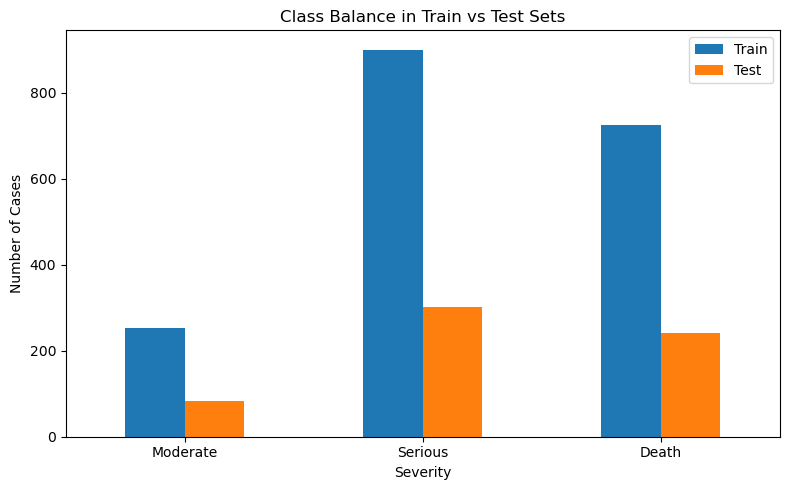

In [60]:
# Compare class balance in the training and testing sets

train_counts = y_train.value_counts().reindex(["Moderate", "Serious", "Death"])
test_counts = y_test.value_counts().reindex(["Moderate", "Serious", "Death"])

balance_df = pd.DataFrame({
    "Train": train_counts,
    "Test": test_counts
})

ax = balance_df.plot(kind="bar", figsize=(8, 5))
plt.title("Class Balance in Train vs Test Sets")
plt.xlabel("Severity")
plt.ylabel("Number of Cases")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Confusion Matrix

The confusion matrix is used to see how well the model’s predictions match the actual severity outcomes.

It breaks the results into a grid where:

* Each row represents the actual severity
* Each column represents the predicted severity

This makes it easy to see where the model is getting things right and where it’s making mistakes. For example, you can see if the model is confusing “Serious” cases with “Death,” or if it tends to miss “Moderate” cases.

Looking at the confusion matrix helps identify patterns in the errors, not just overall accuracy. This is especially useful when the classes are imbalanced, since accuracy alone can be misleading.

Overall, this step gives a clearer picture of how the model is performing across each severity level.


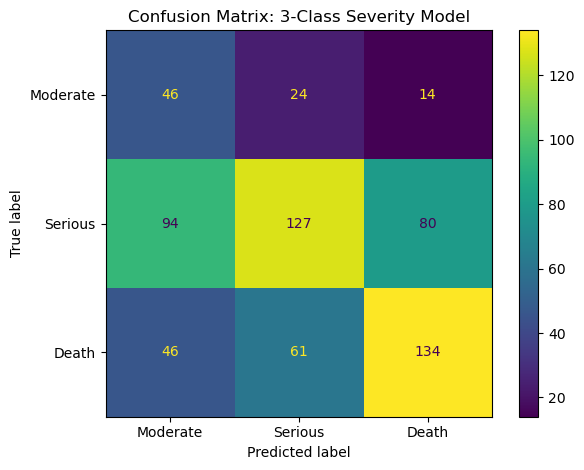

In [61]:
# Confusion matrix

labels = ["Moderate", "Serious", "Death"]
cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()
plt.title("Confusion Matrix: 3-Class Severity Model")
plt.tight_layout()
plt.show()

### Normalized confusion matrix

The normalized version makes it easier to compare model performance across classes with different sample sizes.


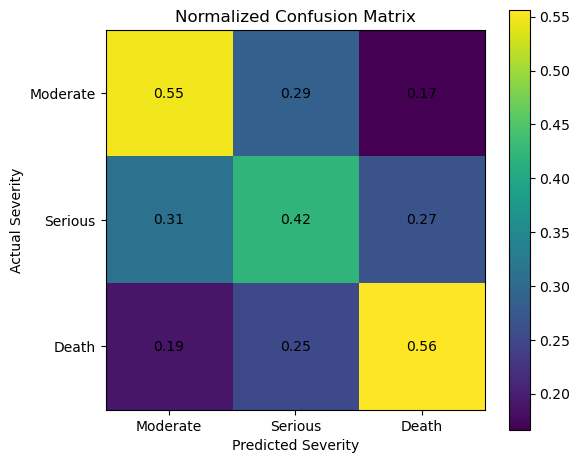

In [62]:
# Normalized confusion matrix

cm_normalized = confusion_matrix(y_test, y_pred, labels=labels, normalize="true")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_normalized)

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel("Predicted Severity")
ax.set_ylabel("Actual Severity")
ax.set_title("Normalized Confusion Matrix")

for row in range(cm_normalized.shape[0]):
    for col in range(cm_normalized.shape[1]):
        ax.text(col, row, f"{cm_normalized[row, col]:.2f}", ha="center", va="center")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


### Model Coefficients by Severity Class

This step extracts the coefficients from the trained logistic regression model so we can understand how each feature is influencing the predictions.

Each feature gets a coefficient for each severity class (Moderate, Serious, Death). These values show how strongly that feature pushes the model toward a specific outcome.

* **Positive coefficients** mean the feature increases the likelihood of that severity level
* **Negative coefficients** mean the feature decreases the likelihood

The output is organized into a table where:

* Rows represent the severity classes
* Columns represent the features used in the model

This makes it easier to compare how the same feature behaves across different severity levels.

Looking at these coefficients helps identify which factors are most associated with higher severity outcomes, and which ones are more linked to lower severity cases.

Overall, this step is mainly about interpreting the model and understanding what it has learned from the data.


In [63]:
# Extract model coefficients by class
# Positive coefficients mean a feature pushes predictions toward that class.

feature_names = model.named_steps["preprocessor"].get_feature_names_out()

coef_df = pd.DataFrame(
    model.named_steps["classifier"].coef_,
    index=model.named_steps["classifier"].classes_,
    columns=feature_names
).T

coef_df.head()

,Death,Moderate,Serious
cat__llm_experience_level_expert,0.168429,-0.217667,0.049238
cat__llm_experience_level_intermediate,-0.144072,-0.082924,0.226997
cat__llm_experience_level_novice,-0.249242,0.377688,-0.128446
cat__llm_experience_level_unknown,0.135664,-0.030043,-0.105621
cat__llm_rescue_type_professional_rescue,-0.112928,-0.001633,0.114561


### Top model coefficients by class

These charts show the strongest positive coefficients for each severity class. Larger positive values mean the feature pushes predictions more toward that class.


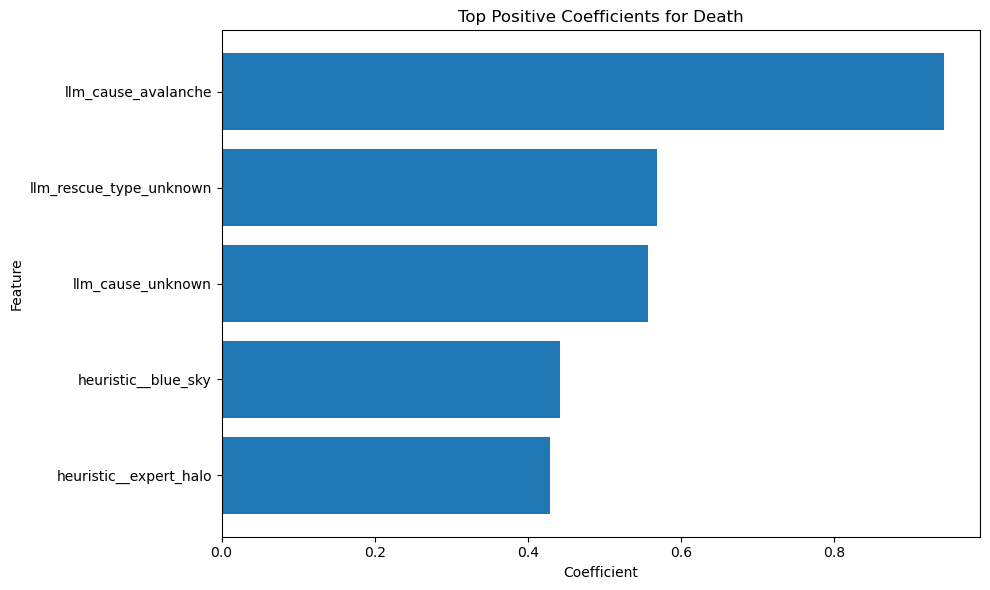

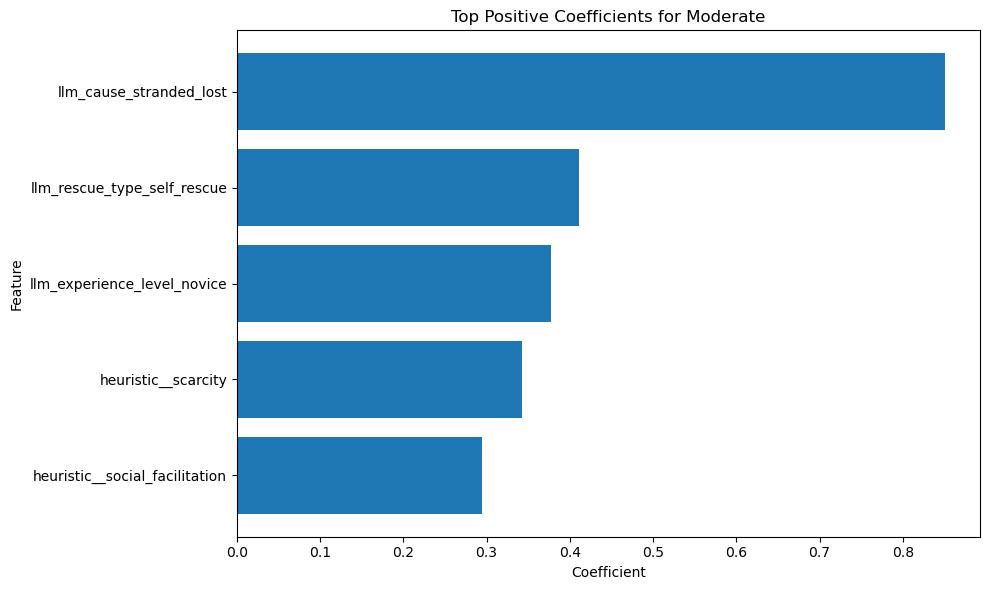

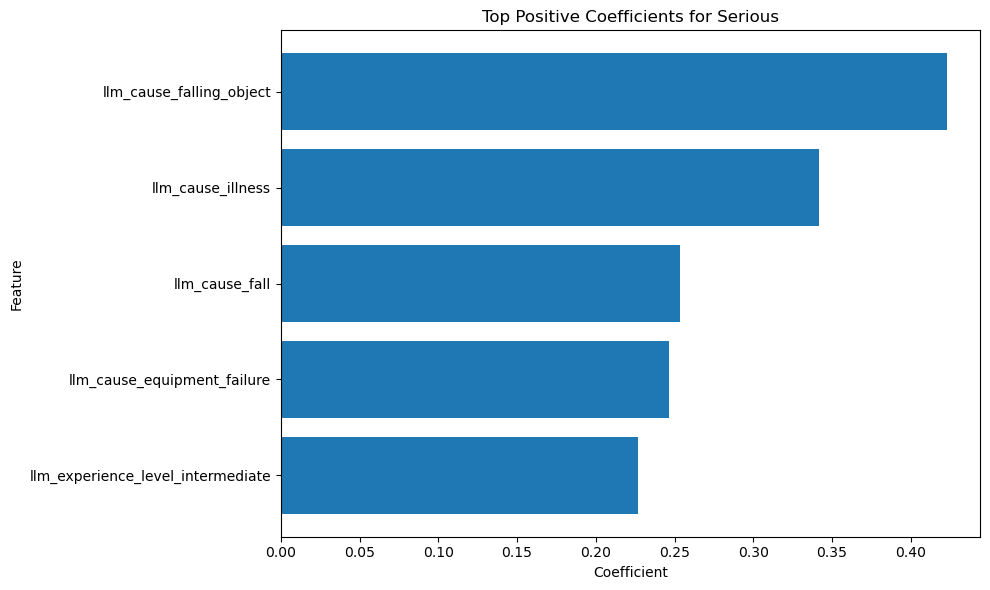

In [65]:
# Plot the top positive coefficients for each severity class

for severity_class in coef_df.columns:
    top_features = coef_df[severity_class].sort_values(ascending=False).head(5).sort_values()

    clean_index = (
        top_features.index
        .str.replace("cat__", "", regex=False)
        .str.replace("num__", "", regex=False)
        .str.replace("bin__", "", regex=False)
    )

    plt.figure(figsize=(10, 6))
    plt.barh(clean_index, top_features.values)
    plt.title(f"Top Positive Coefficients for {severity_class}")
    plt.xlabel("Coefficient")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

In [35]:
# Show the strongest positive and negative predictors for each severity class

for severity_class in coef_df.columns:
    print("=" * 80)
    print(f"CLASS: {severity_class}")
    print("\nTop positive predictors:")
    print(coef_df[severity_class].sort_values(ascending=False).head(20))
    print("\nTop negative predictors:")
    print(coef_df[severity_class].sort_values(ascending=True).head(20))
    print()

CLASS: Death

Top positive predictors:
cat__llm_cause_avalanche             0.943689
cat__llm_rescue_type_unknown         0.568596
cat__llm_cause_unknown               0.557697
bin__heuristic__blue_sky             0.442276
bin__heuristic__expert_halo          0.428685
bin__heuristic__consistency          0.388143
bin__climb_tag__alpine               0.326149
bin__climb_tag__rock                 0.271055
bin__heuristic__familiarity          0.262469
cat__climb_primary_unknown           0.209735
cat__Rope_no_rope                    0.196129
cat__llm_participants_gender_men     0.179929
cat__llm_experience_level_expert     0.168429
cat__Helmet_no_helmet                0.164217
cat__llm_experience_level_unknown    0.135664
bin__heuristic__acceptance           0.132453
num__llm_people_involved             0.106610
cat__llm_participants_gender_both    0.071396
bin__heuristic__back_to_the_barn     0.052132
cat__llm_cause_weather_exposure      0.016498
Name: Death, dtype: float64

Top negative

### Odds Ratios for Model Interpretation

In this step, the model coefficients are converted into **odds ratios** to make them easier to interpret.

Logistic regression coefficients are in log-odds form, which can be hard to understand directly. By taking the exponential of those values, we get odds ratios that are more intuitive.

* Values **greater than 1** mean the feature increases the likelihood of that severity level
* Values **less than 1** mean the feature decreases the likelihood

For each severity class, the code prints:

* The features with the **highest odds ratios** (strongest positive association)
* The features with the **lowest odds ratios** (strongest negative association)

This helps highlight which factors are most strongly linked to each severity outcome.

Overall, this step makes it easier to interpret the model results and identify which features are driving higher or lower severity predictions.


In [36]:
# Odds ratios for easier interpretation
# Values > 1 increase the odds of that class
# Values < 1 decrease the odds of that class

odds_ratio_df = np.exp(coef_df)

for severity_class in odds_ratio_df.columns:
    print("=" * 80)
    print(f"CLASS: {severity_class}")
    print("\nHighest odds ratios:")
    print(odds_ratio_df[severity_class].sort_values(ascending=False).head(20))
    print("\nLowest odds ratios:")
    print(odds_ratio_df[severity_class].sort_values(ascending=True).head(20))
    print()

CLASS: Death

Highest odds ratios:
cat__llm_cause_avalanche             2.569442
cat__llm_rescue_type_unknown         1.765786
cat__llm_cause_unknown               1.746645
bin__heuristic__blue_sky             1.556245
bin__heuristic__expert_halo          1.535238
bin__heuristic__consistency          1.474241
bin__climb_tag__alpine               1.385621
bin__climb_tag__rock                 1.311347
bin__heuristic__familiarity          1.300136
cat__climb_primary_unknown           1.233352
cat__Rope_no_rope                    1.216684
cat__llm_participants_gender_men     1.197133
cat__llm_experience_level_expert     1.183444
cat__Helmet_no_helmet                1.178470
cat__llm_experience_level_unknown    1.145297
bin__heuristic__acceptance           1.141625
num__llm_people_involved             1.112500
cat__llm_participants_gender_both    1.074007
bin__heuristic__back_to_the_barn     1.053515
cat__llm_cause_weather_exposure      1.016635
Name: Death, dtype: float64

Lowest odds rati

## How to interpret the above output

- Features with large **positive coefficients** for `Death` are associated with a higher probability of the `Death` class.
- Features with large **positive coefficients** for `Serious` are associated with a higher probability of the `Serious` class.
- Features with large **positive coefficients** for `Moderate` are associated with a higher probability of the `Moderate` class.

### Feature prefixes
- `cat__` → one-hot encoded categorical variables
- `num__` → scaled numeric variables
- `bin__` → binary tag indicators created from multi-tag columns

Examples:
- `cat__llm_cause_fall`
- `cat__Helmet_no_helmet`
- `bin__heuristic__familiarity`
- `bin__climb_tag__ice`

### Model Results and Key Takeaways

Overall, the model achieved about **49% accuracy**, which is reasonable given the complexity of the problem and the imbalance between severity classes. It performed best at identifying **Death** and **Serious** cases, while **Moderate** cases were harder to classify consistently.

Looking at the coefficients and odds ratios, a few clear patterns stand out.

One of the strongest predictors of **Death** was the **type of incident**, especially `avalanche` and cases where the cause was marked as `unknown`. These both significantly increased the likelihood of a fatal outcome. Certain heuristics like **“blue sky”** and **“expert halo”** also showed up as contributors, suggesting that overconfidence and favorable conditions may play a role in higher-risk decisions. Alpine and rock environments also leaned more toward fatal outcomes compared to others.

On the other hand, incidents involving **self-rescue**, **being stranded/lost**, or **equipment failure** were much less likely to result in death and were more associated with lower severity outcomes.

For **Moderate** severity, the strongest signals were cases involving being **stranded or lost**, **self-rescue situations**, and **novice experience levels**. These tend to reflect situations that are risky but not immediately life-threatening. Some heuristics like **“back to the barn”** and **scarcity** also appeared here, which may point to decision-making under pressure but without catastrophic consequences.

For **Serious** injuries, the model highlighted more direct physical causes like **falls**, **falling objects**, and **equipment failure**. These are incidents where injury is likely but not always fatal. Use of a **rope** and **helmet** also showed up as associated with serious outcomes, which likely reflects that these incidents happen in more technical climbing environments rather than indicating those factors increase risk.

A key takeaway is that **cause-related features and heuristics were much more informative than most individual tag columns**. The heuristics in particular added useful context around decision-making and behavior that isn’t captured by standard tags alone.

In summary, the model suggests that:

* High-severity outcomes are strongly tied to **objective hazards** (like avalanches) and **decision-making biases**
* Moderate outcomes are more associated with **navigational or situational issues** (like being lost or stranded)
* Serious injuries sit in between, often linked to **falls and equipment-related incidents**

These results give a useful starting point for understanding which factors are most associated with severity, while also highlighting areas where additional data or refinement could improve the model.


### Ethical Considerations

This project directly examines incidents involving individuals participating in mountaineering activities, including climbing, skiing, and alpine traversing. The dataset consists of reported incidents that, in some cases, may be identifiable due to the unique nature of specific events. However, these incidents were self-reported and publicly documented, suggesting that consent for publication was likely obtained.

There are important ethical considerations regarding how this analysis may influence public perception. One potential unintended consequence is that findings could discourage participation in outdoor activities by emphasizing risk without sufficient context. It is therefore important that results are communicated responsibly, highlighting both the inherent risks and the role of preparation, training, and safety practices.

This work may also intersect with the guidance provided by established alpine organizations such as the American Alpine Club, the International Climbing and Mountaineering Federation (UIAA), and the International Federation of Mountain Guides Associations (IFMGA). These organizations are widely respected for promoting safe practices, including recommendations on equipment, route selection, and decision-making in alpine environments. While this analysis may highlight trends or gaps, it is not intended to challenge or replace established safety standards, but rather to complement ongoing efforts to improve safety.

Gear manufacturers are also indirect stakeholders. These companies design equipment to meet rigorous safety standards and minimize risk to users. Although this project does not aim to evaluate or critique specific brands, any references to equipment in incident reports should be interpreted cautiously, particularly when determining whether gear failure, misuse, or external factors contributed to an outcome.

Additionally, medical professionals and search and rescue teams are important stakeholders. Insights from this analysis may help inform resource allocation, training priorities, and response strategies. However, these applications are primarily reactive and do not directly prevent incidents.

Throughout this project, care has been taken to avoid the use of personally identifiable information (PII) and to interpret findings in a way that does not stigmatize individuals, groups, or locations. The goal is to contribute to a broader understanding of safety in alpine environments while promoting responsible and ethical use of data.

---

### Conclusion

This combined analysis integrates spatial, temporal, and severity-based perspectives to provide a more comprehensive understanding of patterns within mountaineering-related incidents. By examining trends across multiple dimensions, the results offer deeper insight than any single approach alone.

While the findings highlight meaningful relationships and potential risk factors, they should be interpreted within the context of the dataset’s limitations, including reporting bias and variability in incident documentation. These results are best viewed as a foundation for further research, safety improvements, and informed decision-making rather than definitive conclusions.

Ultimately, this work aims to support safer participation in alpine environments by contributing to ongoing discussions around risk awareness, preparation, and responsible outdoor practices.